# **An Exploration of Machine Learning for Neurocomputational Mechanisms of Human Multisensory Learning**

## **Abstract**

This project explores the application of machine learning to predicting neural signals related to human reinforcement learning, focusing on whether shared modeling of separate but connected signals improves prediction performance. Using a BIDS-formatted fMRI dataset from 58 participants performing a multisensory reinforcement learning task across six runs, preprocessed with fMRIPrep and reduced to ROI-level features, this project investigates events in which the learning signals value (V) and surprise are defined. For each event, BOLD activity is extracted following an HRF delay and used to predict V and surprise either independently or jointly. Performance is evaluated using R-squared, mean squared error, and Pearson correlation, along with statistical comparisons between modeling approaches.

The original hypothesis, that shared neural representations of V and surprise had a significant effect on prediction performance, and that multi-task (MT) methods might generalize better than single-task (ST) methods because the signals are supported by a shared neurocomputational mechanism, could not be definitively proven. Models across linear and more advanced approaches struggled to learn from averaged window activations, and no model achieved an MSE below 0.985. MT models underperformed ST models, supporting the claim of Bedi et al. (2026) that the two signals arise from connected but distinct neural structures, and highlighting the difficulty of finding a BOLD encoding scheme.



---

## **Environment and reproducibility setup**


In [ ]:
# Install packages used by the compact Colab notebook
!pip -q install nilearn nibabel scikit-learn wandb importnb torch numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.7 MB/s eta 0:00:00


In [1]:
REPO_URL = "https://github.com/Embra-Schuilenburg/machine-learning-mechanism-of-multisensory-learning.git"
REPO_BRANCH = "master"

!git clone --depth 1 --branch {REPO_BRANCH} {REPO_URL} project_repo

import os
import sys
from pathlib import Path

PROJECT_DIR = Path("/content/project_repo")
DATA_DIR = Path("/content")
PROCESSED_DATA_DIR = Path("/content/project_repo/processed_data")

sys.path.append(str(PROJECT_DIR / "src"))
sys.path.append(str(PROJECT_DIR))


fatal: destination path 'project_repo' already exists and is not an empty directory.


In [2]:
import copy
import json
import os
import pickle
import pprint
import random
from pathlib import Path
from helper_functions import load_saved_run

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import sklearn as sk
import torch
import torch.nn as nn
import wandb

from nilearn.datasets import fetch_atlas_schaefer_2018
from nilearn.maskers import NiftiLabelsMasker
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

SEED = 67
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Processed data directory exists:", PROCESSED_DATA_DIR.exists())
if not PROCESSED_DATA_DIR.exists():
  print('please go to the github linked at the top of this block, download the processed data directory (25MB) and add it to a directory in project_repo/')


Using device: cpu
Processed data directory exists: True


## **Introduction**

Neuroimaging is the use of digital technologies to study the physiology of central nervous systems. It's a field with broad applications and many methods, one of which is functional magnetic resonance imaging (fMRI). fMRI detects and images brain activity by measuring the flow of blood through different parts of the brain. The underlying principles of fMRI imaging are that:

1) as parts of the brain activate, the oxygenated blood within them becomes deoxygenated, and is replaced by a flow of new oxygenated blood; and
2) the way magnetic frequencies passing through blood behave changes depending on the oxygen level of the blood.

These two facts form the basis of blood-oxygen-level contrast (BOLD), and enable fMRI machines to effectively visualize the activity of the brain in four dimensions (xyz coordinates, and time).

fMRI has broad applications in modern healthcare and research contexts. In the paper pre-print which inspired this project, in [1] key signals related to human multi-sensory learning: choice-phase value (V) and surprise, among others, are identified. V is a representation of the value of a choice made in a multisensory learning task; and surprise, known as Shannon surprise, is a representation of how unexpected a stimulus is, which is separate from the reward of a person’s choice (in the protocol of the original paper, reward was the feedback on a choice a person received, not an actual reward).

It was shown in [1] that fMRI may encode V and surprise through the use of fMRI data from a multisensory learning experiment to identify areas of the brain related to these signals through the use of general linear models (GLMs). In [1], 58 participants completed a multisensory reinforcement learning task in which correct responses depended on combinations of visual and auditory or tactile cues rather than on any single sensory input alone. As participants completed the learning task, fMRI data was collected on them and associated with choice and feedback events. The authors showed that the previously identified signals are supported by separate but partly complementary neural systems. In particular, their results suggest that reinforcement-related and structure-related learning signals can be separated computationally, while still interacting within broader multisensory learning networks.

The fact that these signals can be represented through fMRI data begs the question of whether or not the values of these signals could be decoded from raw fMRI data. The present project builds on [1]'s work and tries to answer the aforementioned question from a machine learning (ML) perspective. Rather than using model-based fMRI analysis to identify where these signals are represented, this project asks whether preprocessed ROI-level BOLD activity can be used to predict the learning variables V and surprise themselves through regression. Furthermore, if the two signals rely on partially shared neural information, then joint modeling may improve performance relative to training separate models for each target. The central research question is therefore whether V and surprise can be decoded from ROI-based fMRI features, and whether MT learning provides an advantage over ST approaches.

To investigate these questions, this project uses the BIDS-formatted fMRI dataset of [1], [2], which was collected from participants performing the reinforcement learning task across six runs, with each run containing 120 trials (60 choice-based and 60 feedback-based). The imaging data is preprocessed with fMRIPrep, then reduced from voxel-based representations to region-of-interest (ROI)-level representations to make downstream modeling more computationally manageable and less vulnerable to overfitting. From these processed runs, choice-phase events were aligned with their corresponding learning targets, and BOLD activity was extracted after an appropriate hemodynamic response delay so that each event could be represented as a feature vector paired with a V or surprise label. This framing turns the problem into a supervised learning task in which neural activity is used to predict latent computational signals associated with learning from brain ROIs.

## **Methodology**

This project consisted of two main stages: preprocessing the neuroimaging data into a machine-learning-ready representation, and evaluating a set of ST and MT predictive models on the resulting inputs. Starting from the BIDS-formatted dataset used in [1], the fMRI runs were first preprocessed using a free preprocessing software called fMRIPrep. This produced standardized and cleaned imaging data suitable for downstream analysis by correcting for head motion that occurred during fMRI recording, denoising measurements, and identifying per-subject confounds to be removed later. To reduce dimensionality and improve tractability, the data was then transformed from voxel-level space into ROI-level representations using the Python package Nilearn and the Schaefer atlas developed at the Montreal Neurological Institute [3]. This step made the learning problem more computationally manageable while also helping limit overfitting, since the number of features was greatly reduced relative to the original voxel space (which contains over 200,000 points of activity per trial).

After preprocessing, choice-phase events were aligned with their corresponding target variables, namely V and surprise. Because the BOLD response is delayed relative to neural activity, an appropriate hemodynamic lag was applied before extracting the ROI activations associated with each event. Each trial was therefore represented as a feature vector describing ROI-level BOLD activity, paired with the relevant learning signal label. Since learning in the task was sequential and each trial depended on previous trials within the same run, runs were treated as the natural modeling unit. In practice, each run was represented as a 60 x 100 matrix, where rows corresponded to trials and columns corresponded to the 100 extracted ROIs.

Using these processed inputs, several ML methods were tested. First, ST linear models were used as a baseline, with separate models trained to predict V and surprise independently. These models provided a simple and interpretable reference point for evaluating whether the ROI-level features contained decodable signal. Next, a MT ElasticNet model was tested to examine whether jointly learning both targets could improve performance. By combining MT learning with regularization, the ElasticNet model was designed to exploit potential overlap in the neural information underlying V and surprise while still preventing potential overfitting with L1/L2 regularization and a limited capacity. All linear models were trained on flattened versions of the inputs in which the ROIs of a single trial formed one input vector, and all trials in a run were considered separate inputs.

Second and lastly, convolutional neural network (CNN) approaches were evaluated in both ST and MT settings. CNNs were chosen on the basis that their ability to capture local patterns could improve predictive performance by capturing the within-run temporal relationship between trials. The ST CNNs were trained separately for each target, allowing the models to learn more complex nonlinear patterns in the run-level ROI activation matrices. In parallel, a multi-task CNN (MT CNN) was tested to determine whether a shared deep representation could better capture structure common to both learning signals. Comparing the ST linear models, MT ElasticNet, ST CNN, and MT CNN made it possible to assess two central methodological questions: whether nonlinear models provide an advantage over simpler linear baselines, and whether joint prediction of V and surprise improves decoding relative to modeling each target separately.

From here, this report will first walk through the code that implements the preprocessing pipeline used in this project, and then it will present the code used to implement and run the models. Data preprocessing will be shown; however, these blocks should not be run, as processing even a single subject can take over an hour on a high-performance workstation computer. An example of a run of one subject will be shown to demonstrate what exactly was processed, and then the fully processed dataset will be imported.

## **Preprocessing pipeline**

First, lets load a single run of a single subject to get an idea of what the original dataset looked like:

In [33]:
example_run = pd.read_csv("/content/project_repo/example_files/sub-01/func/sub-01_task-learn_run-1_events.tsv")
example_run

,onset\tduration\ttrial_type\tparam_surprise\tparam_V\tparam_rpe
0,3.47770013161835\t2.22617716838158\tChoiceTact...
1,7.22228203106124\t1.0000000000000009\tFeedback...
2,11.1003976227662\t1.87931707723374\tChoiceTact...
3,15.2427180700292\t0.9999999999999982\tFeedback...
4,19.372291248174\t2.3994249518264\tChoiceTactil...
...,...
115,475.647850736488\t1.0\tFeedbackTactile\t\t\t0....
116,479.561975342634\t2.18302365736599\tChoiceTact...
117,483.903011708399\t1.0\tFeedbackTactile\t\t\t-1...
118,487.568465514204\t2.42245018579524\tChoiceTact...


In this run we can see all of the relevant details of its trials, note specifically we can see the trial type, when it happened, and the values of V and surprise. Now I'll show you its accompanying BOLD image (at one time and location in the trial).

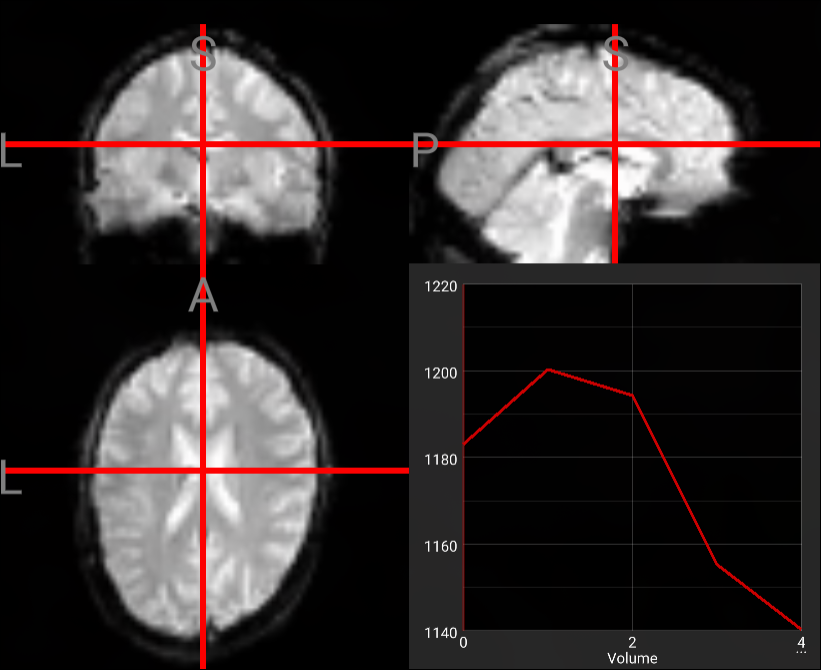

Now let's look at the code used for preprocessing the data. Note that only the nilearn processing part was is shown since fMRIPrep was ran with a script so I didn't have to sit with it for the 36 hrs it ran. fMRIPrep was run with the flags:
- Hardware flags:
    - NTHREADS=8
    - OMP_NTHREADS=4
    - MEM_MB=24000
- Processing flags:
    - --fs-no-reconall
    - --skip-bids-validation
    - --output-spaces MNI152NLin2009cAsym

Most of the flags aren't important; but note the output space. It will be seen again soon.


*Kindly also note that much of the following code is included for the reference of the reader the following two sections can be mostly skimmed as they don't contain much actual machine learning yet.*

#### **Basic preprocessing methods**

In [3]:
########################################################################
# May be run, shows some ROIs from the atlas
########################################################################

# Project paths

PROJECT_DIR = Path(
    '/media/peripheral/Code/Comp432/machine-learning-mechanism-of-multisensory-learning/')
ORIG_DATASET_DIR = PROJECT_DIR / 'original-dataset'
DERIVATIVES_DIR = Path('/media/peripheral/Code/Comp432/dataset/derivatives/')
OUTPUT_DIR = PROJECT_DIR / 'processed_data'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# Load atlas (this is the atlas refered to earlier which will be used to extract ROIs)

def load_schaefer_100_atlas():
    atlas = fetch_atlas_schaefer_2018(
        n_rois=100,
        yeo_networks=7,
        resolution_mm=2
    )

    atlas_maps = atlas.maps
    atlas_labels = [
        lab.decode('utf-8') if isinstance(lab, bytes) else str(lab)
        for lab in atlas.labels
    ]

    # Remove background label if present
    if len(atlas_labels) > 0 and atlas_labels[0].lower() == 'background':
        atlas_labels = atlas_labels[1:]

    return atlas_maps, atlas_labels


atlas_maps, atlas_labels = load_schaefer_100_atlas()
print(f'Number of ROIs: {len(atlas_labels)}')
print(atlas_labels[:5])


# File path helpers

def get_subject_ids(original_dataset_dir):
    """
    Return sorted subject IDs like ['sub-01', 'sub-02', ...]
    based on the original dataset directory.
    """
    return sorted([p.name for p in original_dataset_dir.iterdir() if p.is_dir() and p.name.startswith('sub-')])


def get_run_file_paths(subject_id, run_number):
    """
    Build the expected paths for one subject/run.

    Returns
    -------
    dict with keys:
        bold, bold_json, confounds_tsv, events_tsv
    """
    run_str = f'run-{run_number}'

    bold = DERIVATIVES_DIR / subject_id / 'func' / (
        f'{subject_id}_task-learn_{run_str}_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz'
    )
    bold_json = DERIVATIVES_DIR / subject_id / 'func' / (
        f'{subject_id}_task-learn_{run_str}_space-MNI152NLin2009cAsym_desc-preproc_bold.json'
    )
    confounds_tsv = DERIVATIVES_DIR / subject_id / 'func' / (
        f'{subject_id}_task-learn_{run_str}_desc-confounds_timeseries.tsv'
    )
    events_tsv = ORIG_DATASET_DIR / subject_id / 'func' / (
        f'{subject_id}_task-learn_{run_str}_events.tsv'
    )

    return {
        'bold': bold,
        'bold_json': bold_json,
        'confounds_tsv': confounds_tsv,
        'events_tsv': events_tsv,
    }


def run_files_exist(run_paths):
    """Check whether all required files exist for a run."""
    return all(path.exists() for path in run_paths.values())


def get_available_runs(subject_id, max_runs=10):
    """
    Return all run numbers that exist for a subject.
    """
    available = []
    for run_number in range(1, max_runs + 1):
        run_paths = get_run_file_paths(subject_id, run_number)
        if run_files_exist(run_paths):
            available.append(run_number)
    return available


# Load simple fMRIPrep confounds (these were produced by fMRIprep)

def load_simple_confounds(confounds_tsv_path, use_global_signal=True):
    """
    Load a simple confound set from fMRIPrep confounds TSV.

    Included by default:
    - 6 rigid-body motion params
    - white_matter
    - csf
    - optional global_signal
    - any non_steady_state_outlier columns

    Returns
    -------
    confounds_df : pd.DataFrame
        Numeric confounds matrix ready for nuisance regression.
    """
    confounds = pd.read_csv(confounds_tsv_path, sep='\t')

    base_cols = [
        'trans_x', 'trans_y', 'trans_z',
        'rot_x', 'rot_y', 'rot_z',
        'white_matter', 'csf'
    ]

    if use_global_signal and 'global_signal' in confounds.columns:
        base_cols.append('global_signal')

    nonsteady_cols = [c for c in confounds.columns if c.startswith(
        'non_steady_state_outlier')]

    selected_cols = [
        c for c in base_cols if c in confounds.columns] + nonsteady_cols

    if len(selected_cols) == 0:
        raise ValueError(
            f'No expected confound columns found in {confounds_tsv_path}')

    confounds_df = confounds[selected_cols].copy()

    # Fill NaNs conservatively so masker regression does not fail
    confounds_df = confounds_df.fillna(0.0)

    return confounds_df

[fetch_atlas_schaefer_2018] Dataset found in /root/nilearn_data/schaefer_2018

Number of ROIs: 100
['7Networks_LH_Vis_1', '7Networks_LH_Vis_2', '7Networks_LH_Vis_3', '7Networks_LH_Vis_4', '7Networks_LH_Vis_5']


#### **ROI matrix construction**

In [4]:
########################################################################
# FOR REFERENCE ONLY, DO NOT RUN - WILL FAIL, OUTPUT PROVIDED AT THE END
########################################################################

# Extract ROI time series for one run

def extract_run_roi_timeseries(
    bold_path,
    atlas_maps,
    confounds_df=None,
    standardize='zscore_sample',  # Specified to use in nilearn documentation
    detrend=True
):
    """
    Extract ROI time series from one preprocessed BOLD run. During extraction signals are normalized by the masker, which:

    1. centers each time series
    2. scales each time series (within a run)
    3. reduces scale across ROIs and runs

    This run-level standardization ensures that ROI activations within a run have approximately means = 0 and unit variance across time.

    Parameters
    ----------
    bold_path : path-like
        Preprocessed fMRIPrep BOLD NIfTI in MNI space.
    atlas_maps : path-like
        Schaefer atlas label image.
    confounds_df : pd.DataFrame or None
        Confounds to regress out.
    standardize : bool
        Standardize each ROI time series.
    detrend : bool
        Detrend ROI time series.

    Returns
    -------
    roi_ts : np.ndarray, shape (n_timepoints, n_rois)
    """
    masker = NiftiLabelsMasker(
        labels_img=atlas_maps,
        standardize=standardize,
        detrend=detrend,
        t_r=None,   # not applying explicit temporal filtering here, performed at event alignment
        verbose=0
    )

    roi_ts = masker.fit_transform(str(bold_path), confounds=confounds_df)
    return roi_ts


# Load and prepare events

def load_run_events(events_tsv_path):
    """
    Load the run events TSV and keep relevant columns.

    Required columns:
    - onset
    - duration
    - trial_type
    - param_surprise
    - param_V

    Returns
    -------
    events_df : pd.DataFrame
    """
    events = pd.read_csv(events_tsv_path, sep='\t')

    required_cols = ['onset', 'duration',
                     'trial_type', 'param_surprise', 'param_V']
    missing = [c for c in required_cols if c not in events.columns]
    if missing:
        raise ValueError(f'Missing columns in {events_tsv_path}: {missing}')

    # Keep only trials with both regression targets present
    events = events.dropna(
        subset=['onset', 'param_surprise', 'param_V']).copy()
    events = events.reset_index(drop=True)

    return events


def add_event_timing_columns(events_df, tr):
    """
    Keep timing in seconds and add helpful TR-boundary columns.

    Note: Changed from previous extraction method to not collapse onset to a single
    rounded TR. Original method can be viewed in back up in archive folder.
    """
    events = events_df.copy()

    events['onset_sec'] = events['onset'].astype(float)
    events['duration_sec'] = events['duration'].astype(float)
    events['offset_sec'] = events['onset_sec'] + events['duration_sec']

    # Optional inspection columns
    events['onset_tr_floor'] = np.floor(events['onset_sec'] / tr).astype(int)
    events['offset_tr_ceil'] = np.ceil(events['offset_sec'] / tr).astype(int)

    return events


    # Build trial feature vectors from run ROI time series

def extract_trial_features_and_labels(
    roi_ts,
    events_df,
    tr,
    hrf_lag_trs=2,
    pre_event_sec=0.0,
    post_event_sec=0.0
):
    """
    Convert run-level ROI time series into one RT-aware averaged feature vector per trial.

    Note: changed from previous version to create an averaged ROI vector from a choice
    duration dependant interval rather than a fixed repetition time window to model windows
    more faithfully to the original publication.

    For each choice event:
        raw choice epoch = [onset, onset + duration]
        BOLD-aligned epoch = [onset + hrf_lag, onset + duration + hrf_lag]

    Optional padding:
        start_sec = onset + hrf_lag - pre_event_sec
        end_sec   = onset + duration + hrf_lag + post_event_sec

    We keep timing in seconds until the final conversion to TR indices.
    That avoids losing sub-TR timing too early.

    Parameters
    ----------
    roi_ts : np.ndarray, shape (n_timepoints, n_rois)
    events_df : pd.DataFrame
        Must include onset_sec and duration_sec (or onset/duration), plus labels.
    tr : float
        Repetition time in seconds.
    hrf_lag_trs : int
        HRF lag measured in TRs. Converted internally to seconds.
    pre_event_sec : float
        Optional seconds to include before the lagged choice epoch.
    post_event_sec : float
        Optional seconds to include after the lagged choice epoch.

    Returns
    -------
    X : np.ndarray, shape (n_trials_kept, n_rois)
    y : np.ndarray, shape (n_trials_kept, 2)
    trial_meta : pd.DataFrame
        Trial metadata aligned row-wise with X and y.
    """
    n_tp, n_rois = roi_ts.shape
    hrf_lag_sec = hrf_lag_trs * tr

    X_list = []
    y_list = []
    kept_rows = []
    meta_rows = []

    for idx, row in events_df.iterrows():
        onset_sec = float(
            row['onset_sec']) if 'onset_sec' in row else float(row['onset'])
        duration_sec = float(
            row['duration_sec']) if 'duration_sec' in row else float(row['duration'])

        # RT-aware lagged choice epoch
        start_sec = onset_sec + hrf_lag_sec - pre_event_sec
        end_sec = onset_sec + duration_sec + hrf_lag_sec + post_event_sec

        # Convert to inclusive TR indices only at the end
        start_tr = int(np.floor(start_sec / tr))
        end_tr = int(np.ceil(end_sec / tr) - 1)

        # Ensure at least one TR is included
        if end_tr < start_tr:
            end_tr = start_tr

        # Skip if window falls outside run
        if start_tr < 0 or end_tr >= n_tp:
            continue

        trial_window = roi_ts[start_tr:end_tr + 1, :]   # inclusive
        trial_feature = trial_window.mean(axis=0)       # shape: (n_rois,)

        X_list.append(trial_feature)
        y_list.append([row['param_surprise'], row['param_V']])
        kept_rows.append(idx)

        meta_row = row.copy()
        meta_row['feature_start_sec'] = start_sec
        meta_row['feature_end_sec'] = end_sec
        meta_row['feature_start_tr'] = start_tr
        meta_row['feature_end_tr'] = end_tr
        meta_row['feature_n_trs'] = end_tr - start_tr + 1
        meta_rows.append(meta_row)

    if len(X_list) == 0:
        raise ValueError('No valid trials remained after RT-aware windowing.')

    X = np.asarray(X_list, dtype=np.float32)
    y = np.asarray(y_list, dtype=np.float32)
    trial_meta = pd.DataFrame(meta_rows).reset_index(drop=True)

    return X, y, trial_meta


# Process one run end-to-end

def process_single_run(
    subject_id,
    run_number,
    atlas_maps,
    use_global_signal=True,
    standardize='zscore_sample',
    detrend=True,
    hrf_lag_trs=2,
    pre_event_sec=0.0,
    post_event_sec=0.0
):
    """
    Process one subject/run into trial-level features and labels.

    Note: this method was updated to process features from the choice dependant
    window rather than the fixed length one.

    Returns
    -------
    run_data : dict
        {
            'X': np.ndarray (n_trials, n_rois),
            'y': np.ndarray (n_trials, 2),
            'trial_meta': pd.DataFrame,
            'tr': float,
            'subject_id': str,
            'run_number': int
        }
    """
    run_paths = get_run_file_paths(subject_id, run_number)
    if not run_files_exist(run_paths):
        raise FileNotFoundError(
            f'Missing files for {subject_id}, run-{run_number}')

    tr = load_tr_from_bold_json(run_paths['bold_json'])
    confounds_df = load_simple_confounds(
        run_paths['confounds_tsv'], use_global_signal=use_global_signal)
    roi_ts = extract_run_roi_timeseries(
        bold_path=run_paths['bold'],
        atlas_maps=atlas_maps,
        confounds_df=confounds_df,
        standardize=standardize,
        detrend=detrend
    )

    events_df = load_run_events(run_paths['events_tsv'])
    events_df = add_event_timing_columns(events_df, tr)

    X, y, trial_meta = extract_trial_features_and_labels(
        roi_ts=roi_ts,
        events_df=events_df,
        tr=tr,
        hrf_lag_trs=hrf_lag_trs,
        pre_event_sec=pre_event_sec,
        post_event_sec=post_event_sec
    )

    return {
        'X': X,
        'y': y,
        'trial_meta': trial_meta,
        'tr': tr,
        'subject_id': subject_id,
        'run_number': run_number
    }


# Save one processed run

def save_run_data(run_data, output_dir, atlas_labels):
    """
    Save one run as:
    - features_and_labels.npz  (arrays for training)
    - trial_metadata.csv       (readable trial table)

    Directory structure:
    processed_data/
        sub-01/
            run-1/
                features_and_labels.npz
                trial_metadata.csv
    """
    subject_id = run_data['subject_id']
    run_number = run_data['run_number']

    run_out_dir = output_dir / subject_id / f'run-{run_number}'
    run_out_dir.mkdir(parents=True, exist_ok=True)

    npz_path = run_out_dir / 'features_and_labels.npz'
    csv_path = run_out_dir / 'trial_metadata.csv'

    np.savez_compressed(
        npz_path,
        X=run_data['X'],                     # (n_trials, n_rois)
        y=run_data['y'],                     # (n_trials, 2)
        y_names=np.array(['param_surprise', 'param_V']),
        roi_names=np.array(atlas_labels),
        tr=np.array(run_data['tr']),
        subject_id=np.array(subject_id),
        run_number=np.array(run_number)
    )

    run_data['trial_meta'].to_csv(csv_path, index=False)

    return npz_path, csv_path


# Process all runs for one participant

def process_subject(
    subject_id,
    atlas_maps,
    atlas_labels,
    output_dir,
    max_runs=10,
    use_global_signal=True,
    standardize='zscore_sample',
    detrend=True,
    hrf_lag_trs=2,      # ~4.67 s lag
    pre_event_sec=0.0,
    post_event_sec=0.0
):
    """
    Process every available run for one subject and save outputs, and skip run processing if run already exists.

    Note: this method was updated average BOLD signals over the choice duration only.

    # TODO: consider adding a .5 to 1.0 second padding to the post event portion of the window.
    """
    subject_dir = os.path.join(output_dir, subject_id)
    run_numbers = get_available_runs(subject_id, max_runs=max_runs)
    print(f'{subject_id}: found runs {run_numbers}')

    saved_files = []

    for run_number in run_numbers:
        run_dir = os.path.join(subject_dir, 'run-' + str(run_number))

        # Check if the run was already processed, if so don't do it again
        if (os.path.isdir(run_dir)):
            continue

        try:
            run_data = process_single_run(
                subject_id=subject_id,
                run_number=run_number,
                atlas_maps=atlas_maps,
                use_global_signal=use_global_signal,
                standardize=standardize,
                detrend=detrend,
                hrf_lag_trs=hrf_lag_trs,
                pre_event_sec=pre_event_sec,
                post_event_sec=post_event_sec
            )

            npz_path, csv_path = save_run_data(
                run_data, output_dir, atlas_labels)
            saved_files.append((npz_path, csv_path))

            print(
                f'  saved run-{run_number}: '
                f'X {run_data['X'].shape}, y {run_data['y'].shape}'
            )

        except Exception as e:
            print(f'  skipped run-{run_number}: {e}')

    return saved_files

######################################################
# DANGER ZONE, COMMENTED TO AVOID ACCIDENTALLY RUNNING
######################################################

# # Process the whole dataset (output hidden due to length)

# subject_ids = get_subject_ids(ORIG_DATASET_DIR)
# print(f'Found {len(subject_ids)} subjects')

# all_saved = []

# for subject_id in subject_ids:
#     saved = process_subject(
#         subject_id=subject_id,
#         atlas_maps=atlas_maps,
#         atlas_labels=atlas_labels,
#         output_dir=OUTPUT_DIR,
#         max_runs=10,
#         use_global_signal=True,
#         standardize='zscore_sample',
#         detrend=True,
#         hrf_lag_trs=2,      # ~4.67 s lag
#         pre_event_sec=0.0,
#         post_event_sec=0.0
#     )
#     all_saved.extend(saved)

# print(f'\nTotal saved run files: {len(all_saved)}')

Example output of this above code:
```
Found 58 subjects
sub-01: found runs [1, 2, 3, 4, 5, 6]
/tmp/ipykernel_254308/2491123346.py:44: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  roi_ts = masker.fit_transform(str(bold_path), confounds=confounds_df)
  saved run-1: X (60, 100), y (60, 2)
/tmp/ipykernel_254308/2491123346.py:44: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  roi_ts = masker.fit_transform(str(bold_path), confounds=confounds_df)
  saved run-2: X (60, 100), y (60, 2)
...
```

In [39]:
# Inspect one saved run

example_npz = Path('/content/project_repo/processed_data/sub-01/run-1/features_and_labels.npz')
example_csv = Path('/content/project_repo/processed_data/sub-01/run-1/trial_metadata.csv')

data = np.load(example_npz, allow_pickle=True)
trial_meta = pd.read_csv(example_csv)


# Visualize data to ensure it was saved correctly

print('X shape:', data['X'].shape)          # (n_trials, 100)
print('y shape:', data['y'].shape)          # (n_trials, 2)
print('y names:', data['y_names'])
print('First 5 ROI names:', data['roi_names'][:5])

display(trial_meta.head())
display(pd.DataFrame(data['y'], columns=data['y_names']))

X shape: (60, 100)
y shape: (60, 2)
y names: ['param_surprise' 'param_V']
First 5 ROI names: ['7Networks_LH_Vis_1' '7Networks_LH_Vis_2' '7Networks_LH_Vis_3'
 '7Networks_LH_Vis_4' '7Networks_LH_Vis_5']


,onset,duration,trial_type,param_surprise,param_V,param_rpe,onset_sec,duration_sec,offset_sec,onset_tr_floor,offset_tr_ceil,feature_start_sec,feature_end_sec,feature_start_tr,feature_end_tr,feature_n_trs
0,3.477700,2.226177,ChoiceTactile,-0.152112,-0.958429,NaN,3.477700,2.226177,5.703877,1,3,8.145380,10.371557,3,4,2
1,11.100398,1.879317,ChoiceTactile,0.143367,-0.958429,NaN,11.100398,1.879317,12.979715,4,6,15.768078,17.647395,6,7,2
2,19.372291,2.399425,ChoiceTactile,0.410659,-0.958429,NaN,19.372291,2.399425,21.771716,8,10,24.039971,26.439396,10,11,2
3,27.596148,2.111797,ChoiceTactile,0.654678,-0.958429,NaN,27.596148,2.111797,29.707946,11,13,32.263828,34.375626,13,14,2
4,35.176328,1.813504,ChoiceTactile,0.879154,-0.958429,NaN,35.176328,1.813504,36.989832,15,16,39.844008,41.657512,17,17,1


,param_surprise,param_V
0,-0.152112,-0.958429
1,0.143367,-0.958429
2,0.410659,-0.958429
3,0.654678,-0.958429
4,0.879154,-0.958429
5,1.086986,-0.958429
6,1.280473,-0.958429
7,1.461468,-0.958429
8,1.631486,-0.958429
9,-0.152112,-0.965513


In [45]:
# Test
X, y_joint, y_surprise, y_V, roi_names, y_names = load_saved_run(example_npz)

print('Input ROIs shape:', X.shape)
print('Joint target shape:', y_joint.shape)
print('Surprise-only shape:', y_surprise.shape)
print('V-only shape:', y_V.shape)

# Full run matrix printout
full_array = np.concatenate([y_joint, X], axis=1)
full_array.shape
df = pd.DataFrame(full_array, columns=np.concatenate(
    [['Surprise', 'V'], data['roi_names']]))

Input ROIs shape: (60, 100)
Joint target shape: (60, 2)
Surprise-only shape: (60,)
V-only shape: (60,)


#### **Quality control**

This code was ran after processing to ensure everything worked. Please run this block to ensure that the uploading of processed data worked so that the machine learning portion code can be run.

In [48]:
# Intialize testing vars
all_tests_passed = True
tests_failed = np.array("/content/project_repo/processed_data")

# Initalize paths (were different on my PC)
output_dir = Path()
OUTPUT_DIR = Path('/content/project_repo/processed_data')


# Quality check 1: structural validation of all saved runs

def validate_saved_run(run_dir):
    npz_path = run_dir / 'features_and_labels.npz'
    csv_path = run_dir / 'trial_metadata.csv'

    result = {
        'run_dir': str(run_dir),
        'ok': True,
        'errors': []
    }

    if not npz_path.exists():
        result['ok'] = False
        result['errors'].append('Missing features_and_labels.npz')
        return result

    if not csv_path.exists():
        result['ok'] = False
        result['errors'].append('Missing trial_metadata.csv')
        return result

    try:
        data = np.load(npz_path, allow_pickle=True)
        meta = pd.read_csv(csv_path)

        X = data['X']
        y = data['y']
        y_names = list(data['y_names'])
        roi_names = data['roi_names']

        if X.ndim != 2:
            result['ok'] = False
            result['errors'].append(f'X should be 2D, got shape {X.shape}')

        if y.ndim != 2:
            result['ok'] = False
            result['errors'].append(f'y should be 2D, got shape {y.shape}')

        if X.shape[0] != y.shape[0]:
            result['ok'] = False
            result['errors'].append(
                f'Mismatch: X rows {X.shape[0]} != y rows {y.shape[0]}')

        if X.shape[0] != len(meta):
            result['ok'] = False
            result['errors'].append(
                f'Mismatch: X rows {X.shape[0]} != metadata rows {len(meta)}')

        if X.shape[1] != 100:
            result['ok'] = False
            result['errors'].append(f'Expected 100 ROIs, got {X.shape[1]}')

        if y.shape[1] != 2:
            result['ok'] = False
            result['errors'].append(f'Expected 2 targets, got {y.shape[1]}')

        if y_names != ['param_surprise', 'param_V']:
            result['ok'] = False
            result['errors'].append(f'Unexpected y_names: {y_names}')

        if len(roi_names) != 100:
            result['ok'] = False
            result['errors'].append(
                f'Expected 100 roi_names, got {len(roi_names)}')

        if not np.isfinite(X).all():
            result['ok'] = False
            result['errors'].append('X contains NaN or inf')

        if not np.isfinite(y).all():
            result['ok'] = False
            result['errors'].append('y contains NaN or inf')

    except Exception as e:
        result['ok'] = False
        result['errors'].append(str(e))

    return result


def validate_all_saved_runs(output_dir):
    run_dirs = sorted(
        [p for p in Path(output_dir).glob('sub-*/run-*') if p.is_dir()])
    results = [validate_saved_run(run_dir) for run_dir in run_dirs]
    return pd.DataFrame(results)


validation_df = validate_all_saved_runs(OUTPUT_DIR)

if (not validation_df[~validation_df['ok'] == 'False'].empty):
    # Show successful runs
    display(validation_df)
    # Show failed runs
    print('Failed runs:')
    display(validation_df[~validation_df['ok'] == 'False'])
    all_tests_passed = False
    tests_failed = tests_failed.append(1)
else:
    print('Test 1 passed')


# Quality check 2: verify y matches trial_metadata exactly

def check_label_alignment(run_dir):
    npz_path = run_dir / 'features_and_labels.npz'
    csv_path = run_dir / 'trial_metadata.csv'

    data = np.load(npz_path, allow_pickle=True)
    meta = pd.read_csv(csv_path)

    y = data['y']
    meta_y = meta[['param_surprise', 'param_V']].to_numpy(dtype=np.float32)

    same = np.allclose(y, meta_y, equal_nan=False)

    return {
        'run_dir': str(run_dir),
        'labels_match_metadata': same,
        'max_abs_diff': float(np.max(np.abs(y - meta_y))) if len(y) > 0 else 0.0
    }


alignment_results = pd.DataFrame([
    check_label_alignment(run_dir)
    for run_dir in sorted(OUTPUT_DIR.glob('sub-*/run-*'))
])

if (not alignment_results[alignment_results['labels_match_metadata'] == False].empty):
    display(
        alignment_results[alignment_results['labels_match_metadata'] == False])
    all_tests_passed = False
    tests_failed = tests_failed.append(2)
else:
    print('Test 2 passed')


# Quality check 3: compare raw event counts to saved trial counts

# This one doesn't need to be run since the original dataset is too large to be uploaded to the notebook

# def summarize_run_trial_counts(subject_id, run_number):
#     run_paths = get_run_file_paths(subject_id, run_number)

#     all_events = pd.read_csv(run_paths['events_tsv'], sep='\t')
#     events = all_events[all_events['param_rpe'] != None]
#     total_events = len(events)

#     valid_label_events = events.dropna(
#         subset=['onset', 'param_surprise', 'param_V'])
#     n_valid_label_events = len(valid_label_events)

#     saved_npz = OUTPUT_DIR / subject_id / \
#         f'run-{run_number}' / 'features_and_labels.npz'
#     if saved_npz.exists():
#         saved_n_trials = np.load(saved_npz, allow_pickle=True)['X'].shape[0]
#     else:
#         saved_n_trials = np.nan

#     return {
#         'subject_id': subject_id,
#         'run_number': run_number,
#         'total_events': total_events,
#         'valid_label_events': n_valid_label_events,
#         'saved_trials': saved_n_trials,
#         'dropped_after_windowing': n_valid_label_events - saved_n_trials if pd.notna(saved_n_trials) else np.nan
#     }


# rows = []
# for subject_id in get_subject_ids(ORIG_DATASET_DIR):
#     for run_number in get_available_runs(subject_id):
#         rows.append(summarize_run_trial_counts(subject_id, run_number))

# trial_count_df = pd.DataFrame(rows)

# if (not trial_count_df[trial_count_df['dropped_after_windowing'] > 0].empty):
#     display(trial_count_df[trial_count_df['dropped_after_windowing'] > 0])
#     all_tests_passed = False
#     tests_failed = tests_failed.append(3)
# else:
#     print('Test 3 passed')

Test 1 passed
Test 2 passed


## **ML experimental setup**

Now that the dataset has been fully preprocessed it can finally be used for machine learning. I'll first declare some helper functions for manipulating the dataset and then jump into each of the models. The following methods utilize lazy-loading in which the dataset isn't acually loaded into memory until it's needed (more useful for CNNs later than the first linear models). No runs or subjects from the original dataset were excluded due to a lack of data.

*The following code can be run however a pre-split split will be loaded after which will to saved datasets and model results later on you'll be able to import to save time when running models.*

*Although preferablly I would have provided a smaller dataset that would have been faster for a reader to run on their own, this dataset already suffers from a small sample size and reducing the size even further would likely create inconsistent results.*

In [5]:
# Data collection method

def collect_run_records(output_dir):
    """
    Find all saved run-level npz files and return records.

    Expected structure:
        output_dir/
            sub-01/
                run-1/
                    features_and_labels.npz
                    trial_metadata.csv
    """
    output_dir = Path(output_dir)
    npz_paths = sorted(output_dir.glob('sub-*/run-*/features_and_labels.npz'))

    if len(npz_paths) == 0:
        raise FileNotFoundError(f'No run files found under: {output_dir}')

    records = []
    for npz_path in npz_paths:
        subject_id = npz_path.parent.parent.name
        run_id = npz_path.parent.name

        records.append({
            'subject_id': subject_id,
            'run_id': run_id,
            'npz_path': npz_path
        })

    return records


# Data splitting method

def split_records_by_subject(records, train_frac=0.70, val_frac=0.15, test_frac=0.15, seed=67, return_subjects=False):
    """
    Split at the subject level to avoid leakage.
    Splits should be passed as decimals between 0.0 and 1.0 and should sum to 1.
    All runs from a subject stay in exactly one split.
    """
    subjects = sorted({rec['subject_id'] for rec in records})
    n_subjects = len(subjects)
    rng = np.random.default_rng(seed)
    rng.shuffle(subjects)

    n_test = max(1, int(round(test_frac * n_subjects)))
    n_val = max(1, int(round(val_frac * n_subjects)))
    n_train = n_subjects - n_val - n_test

    train_subjects = set(subjects[:n_train])
    val_subjects = set(subjects[n_train:n_train + n_val])
    test_subjects = set(subjects[n_train + n_val:])

    train_records = [r for r in records if r['subject_id'] in train_subjects]
    val_records = [r for r in records if r['subject_id'] in val_subjects]
    test_records = [r for r in records if r['subject_id'] in test_subjects]

    if return_subjects:
        return train_records, val_records, test_records, np.array(train_subjects), np.array(val_subjects), np.array(test_subjects)
    else:
        return train_records, val_records, test_records


# Data set

class RunSequenceDataset(Dataset):
    """
    One item = one run.

    Returns:
        x       : [n_trials, n_rois]
        y       : [n_trials]       (single-task target sequence)
        length  : int
    """

    def __init__(self, records, target_name='surprise'):
        self.records = records
        self.target_name = target_name

        if target_name not in {'surprise', 'V'}:
            raise ValueError('target_name must be "surprise" or "V"')

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        X, _, y_surprise, y_V, roi_names, y_names = load_saved_run(
            rec['npz_path'])

        X = X.astype(np.float32)

        if self.target_name == 'surprise':
            y = y_surprise.astype(np.float32)
        else:
            y = y_V.astype(np.float32)

        item = {
            'x': torch.from_numpy(X),   # [n_trials, n_rois]
            'y': torch.from_numpy(y)   # [n_trials]
        }

        return item


# Collect all subject records
records = collect_run_records('/content/project_repo/processed_data')
print(records)

if not os.path.exists('/content/project_repo/splits.pkl'):
    train, val, test, train_subjects, val_subjects, test_subjects = split_records_by_subject(
        records=records,
        train_frac=.8,
        val_frac=.1,
        test_frac=.1,
        seed=SEED,
        return_subjects=True
    )

    with open('splits.pkl', 'wb') as f:
        pickle.dump({
            'train': train,
            'val': val,
            'test': test,
            'train_subjects': train_subjects,
            'val_subjects': val_subjects,
            'test_subjects': test_subjects,
        }, f)
else:
    with open('splits.pkl', 'rb') as f:
        splits = pickle.load(f)

    train = splits['train']
    val = splits['val']
    test = splits['test']
    train_subjects = splits['train_subjects']
    val_subjects = splits['val_subjects']
    test_subjects = splits['test_subjects']

print(train_subjects, '\n', val_subjects, '\n', test_subjects)

[{'subject_id': 'sub-01', 'run_id': 'run-1', 'npz_path': PosixPath('/content/project_repo/processed_data/sub-01/run-1/features_and_labels.npz')}, {'subject_id': 'sub-01', 'run_id': 'run-2', 'npz_path': PosixPath('/content/project_repo/processed_data/sub-01/run-2/features_and_labels.npz')}, {'subject_id': 'sub-01', 'run_id': 'run-3', 'npz_path': PosixPath('/content/project_repo/processed_data/sub-01/run-3/features_and_labels.npz')}, {'subject_id': 'sub-01', 'run_id': 'run-4', 'npz_path': PosixPath('/content/project_repo/processed_data/sub-01/run-4/features_and_labels.npz')}, {'subject_id': 'sub-01', 'run_id': 'run-5', 'npz_path': PosixPath('/content/project_repo/processed_data/sub-01/run-5/features_and_labels.npz')}, {'subject_id': 'sub-01', 'run_id': 'run-6', 'npz_path': PosixPath('/content/project_repo/processed_data/sub-01/run-6/features_and_labels.npz')}, {'subject_id': 'sub-02', 'run_id': 'run-1', 'npz_path': PosixPath('/content/project_repo/processed_data/sub-02/run-1/features_and

### **Data split regime**

The 80 / 10 / 10 split ratio was chosen to maximize the amount of data models could use for training while still leaving enough data for fair validation and testing. The size of the sets are 276 runs, 36 runs, and 36 runs for the train, validation, and testing sets respectively. Please note that careful attention is paid her to split the dataset by subject and not simply by run. This is necessary to prevent data leakage as if runs from the same subject were in multiple sets the model would be evaluated on data that could be very similar to data it had already seen.

### **Linear models**

I chose to assess machine learning capabilities on the dataset using linear models before moving onto more complex models so that later models would have something tangible to be compared against. Linear models provide a simple, interpretable, and well-established baseline for supervised learning on high-dimensional neuroimaging data. In neuroimaging contexts, the number of input features can be large relative to the number of training examples, which increases the risk of overfitting and makes model regularization especially important. The curse of dimensionality is both a major limitation of this project and of the applications of ML for neuroimaging in general. Annoyingly, traditional solutions to the curse of dimensionality such as resampling and data augmentation can't be used easily due to the facts that:

1. neuroimaging data is highly subject- and experiment-specific and non-deterministic, which means that resampling is often not feasible, and
2. in neuroimaging, especially fMRI imaging, there is a high noise-to-signal ratio, which means the introduction of more noise through methods like data augmentation can easily erase learnable patterns in data.

Regularized linear methods are therefore a natural first choice out of available machine learning methods: they are computationally efficient, relatively easy to tune, and allow model performance to be evaluated without introducing the added complexity of deeper nonlinear architectures that may cause overfitting. They also make it easier to determine whether the ROI-level representations contain linearly decodable information about the target signals before testing more flexible models. For ST models I assessed both LASSO and Ridge models.

LASSO was selected because it performs both regularization and feature selection through its L1 penalty. Unlike Ridge, LASSO can drive some coefficients exactly to zero, effectively selecting a smaller subset of input features. This property is especially attractive in high-dimensional settings where only a limited number of ROIs may be strongly related to the prediction target. By encouraging sparsity, LASSO can improve interpretability and reduce the influence of noisy or weakly informative features. For this project, it was useful not only as a predictive model, but also as a way of testing whether the neural information relevant to V and surprise might be concentrated in a relatively compact subset of regions.

Ridge regression was included because it is well suited to settings where many input features may contain small but meaningful amounts of signal. By applying an L2 penalty to the model weights, Ridge shrinks coefficients toward zero without forcing most of them to become exactly zero. This is beneficial when predictive information is distributed across many ROIs rather than concentrated in only a small subset. In neuroimaging data, where features are often correlated and brain regions may contribute jointly rather than independently, Ridge can produce stable solutions. As a result, it serves as a strong baseline when the goal is to preserve diffuse signal while controlling model complexity.

These two ST models each encapsulate separate approaches to the same problem, and represent different interpretations of how neural mechanisms can be best captured. The results of both will be compared later, and by doing so information regarding the neural mechanisms capturing V and surprise will be gleaned.

Both LASSO and Ridge are strong linear models, but they can't be used for MT learning. ElasticNet was selected to address this need, and because it combines the strengths of both Ridge and LASSO by using both L1 and L2 regularization. This makes it particularly useful when features are numerous and correlated, as is often the case with ROI-based fMRI data. In such settings, pure LASSO can behave inconsistently by selecting one feature from a correlated group and discarding the others, while Ridge keeps all correlated features but does not enforce sparsity. ElasticNet provides a compromise: it can retain groups of related predictors while still shrinking unimportant coefficients and encouraging partial sparsity. This made it an especially appropriate model for this project, since the target signals were expected to depend on distributed but potentially overlapping patterns of neural activity across brain regions.

#### **Normalizaton**

One extra bit of work that LASSO, Ridge, and MT ElasticNet require is the normalization of dataset inputs and labels to each have mean = 0 and standard deviation = 1. This is needed because linear models are particularly sensitive the scales of inputs and labels, it's essential to prevent one feature superceding others in importance just because it's larger on average. Inputs are already normalized at the run-level since ROIs are by nature normalized in preprocessing, but the data will now need to be normalized again at the trial level.

In [58]:
# Dataset extraction

X_train_list = []
y_V_train_list = []
y_surprise_train_list = []
X_val_list = []
y_V_val_list = []
y_surprise_val_list = []
X_test_list = []
y_V_test_list = []
y_surprise_test_list = []


for rec in train:
    X_run, _, y_surprise, y_V, roi_names, y_names = load_saved_run(
        rec['npz_path'])
    X_train_list.append(X_run)
    y_V_train_list.append(y_V.reshape(-1, 1))
    y_surprise_train_list.append(y_surprise.reshape(-1, 1))

X_train = np.vstack(X_train_list)
y_V_train = np.vstack(y_V_train_list).ravel()
y_surprise_train = np.vstack(y_surprise_train_list).ravel()

for rec in val:
    X_run, _, y_surprise, y_V, roi_names, y_names = load_saved_run(
        rec['npz_path'])
    X_val_list.append(X_run)
    y_V_val_list.append(y_V.reshape(-1, 1))
    y_surprise_val_list.append(y_surprise.reshape(-1, 1))

X_val = np.vstack(X_val_list)
y_V_val = np.vstack(y_V_val_list).ravel()
y_surprise_val = np.vstack(y_surprise_val_list).ravel()

for rec in test:
    X_run, _, y_surprise, y_V, roi_names, y_names = load_saved_run(
        rec['npz_path'])
    X_test_list.append(X_run)
    y_V_test_list.append(y_V.reshape(-1, 1))
    y_surprise_test_list.append(y_surprise.reshape(-1, 1))

X_test = np.vstack(X_test_list)
y_V_test = np.vstack(y_V_test_list).ravel()
y_surprise_test = np.vstack(y_surprise_test_list).ravel()

print(X_train.shape, y_V_train.shape, y_surprise_train.shape)


# Scale the data since normalization was previously performed at the run level for ROIs and subject level for labels

X_scaler = StandardScaler()
y_V_scaler = StandardScaler()
y_surprise_scaler = StandardScaler()

X_train = X_scaler.fit_transform(X_train)
X_val = X_scaler.transform(X_val)
X_test = X_scaler.transform(X_test)

y_V_train = y_V_scaler.fit_transform(y_V_train.reshape(-1, 1)).ravel()
y_V_val = y_V_scaler.transform(y_V_val.reshape(-1, 1)).ravel()
y_V_test = y_V_scaler.transform(y_V_test.reshape(-1, 1)).ravel()

y_surprise_train = y_surprise_scaler.fit_transform(
    y_surprise_train.reshape(-1, 1)
).ravel()
y_surprise_val = y_surprise_scaler.transform(
    y_surprise_val.reshape(-1, 1)
).ravel()
y_surprise_test = y_surprise_scaler.transform(
    y_surprise_test.reshape(-1, 1)
).ravel()

# Check that scaling worked
print("X_train_scaled mean (first 5 cols):", X_train.mean(axis=0)[:5])
print("X_train_scaled std  (first 5 cols):", X_train.std(axis=0)[:5])
print("y_V_train_scaled mean:", y_V_train.mean())
print("y_V_train_scaled std :", y_V_train.std())
print("y_surprise_train_scaled mean:", y_surprise_train.mean())
print("y_surprise_train_scaled std :", y_surprise_train.std())

(16560, 100) (16560,) (16560,)
X_train_scaled mean (first 5 cols): [ 2.3264956e-08 -1.7283908e-08  5.5019118e-08 -2.4264777e-08
 -1.5610946e-07]
X_train_scaled std  (first 5 cols): [0.9999989  1.0000001  0.99999905 0.9999982  0.9999996 ]
y_V_train_scaled mean: 1.8730832e-08
y_V_train_scaled std : 1.0
y_surprise_train_scaled mean: -1.4973147e-09
y_surprise_train_scaled std : 1.0


#### **Single-task linear model implementations**

In [61]:
# LASSO implementation and alpha tuning

alphas = np.logspace(-4, 1, 30)

print('V:\n')

best_alpha = None
best_val_mse = float('inf')
best_model = None

for alpha in alphas:
    model = sk.linear_model.Lasso(
        alpha=alpha, max_iter=1000000, random_state=SEED)
    model.fit(X_train, y_V_train)

    val_pred = model.predict(X_val)
    val_mse = mean_squared_error(y_V_val, val_pred)

    if val_mse < best_val_mse:
        best_val_mse = val_mse
        best_alpha = alpha
        best_model = model
        print(f"new best alpha={alpha:.5f}  val_mse={val_mse:.6f}")

print('Best alpha: ', best_alpha)
print('Best val MSE: ', best_val_mse)

test_pred = best_model.predict(X_test)
print('Test MSE: ', mean_squared_error(y_V_test, test_pred))
print('Test R^2: ', r2_score(y_V_test, test_pred))

print('-' * 20)
print('surprise:\n')

best_alpha = None
best_val_mse = float('inf')
best_model = None

for alpha in alphas:
    model = sk.linear_model.Lasso(
        alpha=alpha, max_iter=1000000, random_state=SEED)
    model.fit(X_train, y_surprise_train)

    val_pred = model.predict(X_val)
    val_mse = mean_squared_error(y_surprise_val, val_pred)

    if val_mse < best_val_mse:
        best_val_mse = val_mse
        best_alpha = alpha
        best_model = model
        print(f'new best alpha={alpha:.5f}  val_mse={val_mse:.6f}')

print('Best alpha: ', best_alpha)
print('Best val MSE: ', best_val_mse)

test_pred = best_model.predict(X_test)
print('Test MSE: ', mean_squared_error(y_surprise_test, test_pred))
print('Test R^2: ', r2_score(y_surprise_test, test_pred))

V:

new best alpha=0.00010  val_mse=1.000514
new best alpha=0.00015  val_mse=1.000427
new best alpha=0.00022  val_mse=1.000302
new best alpha=0.00033  val_mse=1.000123
new best alpha=0.00049  val_mse=0.999883
new best alpha=0.00073  val_mse=0.999610
new best alpha=0.00108  val_mse=0.999339
new best alpha=0.00161  val_mse=0.999054
new best alpha=0.00240  val_mse=0.998875
new best alpha=0.00356  val_mse=0.998619
new best alpha=0.00530  val_mse=0.998271
Best alpha:  0.005298316906283713
Best val MSE:  0.9982712268829346
Test MSE:  0.995506227016449
Test R^2:  0.0032330751419067383
--------------------
surprise:

new best alpha=0.00010  val_mse=0.994414
new best alpha=0.00015  val_mse=0.994376
new best alpha=0.00022  val_mse=0.994320
new best alpha=0.00033  val_mse=0.994254
new best alpha=0.00049  val_mse=0.994177
new best alpha=0.00073  val_mse=0.994080
new best alpha=0.00108  val_mse=0.994035
new best alpha=0.00161  val_mse=0.993901
new best alpha=0.00240  val_mse=0.993842
Best alpha:  0

In [62]:
# Ridge implementation and alpha tuning

alphas = np.logspace(-4, 1, 30)

print('V:\n')

best_alpha = None
best_val_mse = float('inf')
best_model = None

for alpha in alphas:
    model = sk.linear_model.Ridge(
        alpha=alpha, max_iter=1000000, random_state=SEED)
    model.fit(X_train, y_V_train)

    val_pred = model.predict(X_val)
    val_mse = mean_squared_error(y_V_val, val_pred)

    if val_mse < best_val_mse:
        best_val_mse = val_mse
        best_alpha = alpha
        best_model = model
        print(f'new best alpha={alpha:.5f}  val_mse={val_mse:.6f}')

print('Best alpha: ', best_alpha)
print('Best val MSE: ', best_val_mse)

test_pred = best_model.predict(X_test)
print('Test MSE: ', mean_squared_error(y_V_test, test_pred))
print('Test R^2: ', r2_score(y_V_test, test_pred))

print('-' * 20)
print('surprise:\n')

best_alpha = None
best_val_mse = float('inf')
best_model = None

for alpha in alphas:
    model = sk.linear_model.Ridge(
        alpha=alpha, max_iter=1000000, random_state=SEED)
    model.fit(X_train, y_surprise_train)

    val_pred = model.predict(X_val)
    val_mse = mean_squared_error(y_surprise_val, val_pred)

    if val_mse < best_val_mse:
        best_val_mse = val_mse
        best_alpha = alpha
        best_model = model
        print(f'new best alpha={alpha:.5f}  val_mse={val_mse:.6f}')

print('Best alpha: ', best_alpha)
print('Best val MSE: ', best_val_mse)

test_pred = best_model.predict(X_test)
print('Test MSE: ', mean_squared_error(y_surprise_test, test_pred))
print('Test R^2: ', r2_score(y_surprise_test, test_pred))

V:

new best alpha=0.00010  val_mse=1.000682
new best alpha=0.08532  val_mse=1.000682
new best alpha=0.12690  val_mse=1.000682
new best alpha=0.18874  val_mse=1.000682
new best alpha=0.28072  val_mse=1.000682
new best alpha=0.41753  val_mse=1.000682
new best alpha=0.62102  val_mse=1.000681
new best alpha=0.92367  val_mse=1.000680
new best alpha=1.37382  val_mse=1.000679
new best alpha=2.04336  val_mse=1.000677
new best alpha=3.03920  val_mse=1.000675
new best alpha=4.52035  val_mse=1.000671
new best alpha=6.72336  val_mse=1.000666
new best alpha=10.00000  val_mse=1.000658
Best alpha:  10.0
Best val MSE:  1.0006577968597412
Test MSE:  0.997113049030304
Test R^2:  0.0016242265701293945
--------------------
surprise:

new best alpha=0.00010  val_mse=0.994497
new best alpha=0.03857  val_mse=0.994497
new best alpha=0.12690  val_mse=0.994496
new best alpha=0.18874  val_mse=0.994496
new best alpha=0.28072  val_mse=0.994496
new best alpha=0.41753  val_mse=0.994496
new best alpha=0.62102  val_m

#### **Multi-task ElasticNet Implementation**

In [63]:
# Data concatenation for ElasticNet (labels are concatenated and inputs are already predefined and scaled above)

y_train = np.column_stack([y_V_train, y_surprise_train])
y_val = np.column_stack([y_V_val, y_surprise_val])
y_test = np.column_stack([y_V_test, y_surprise_test])


# ElasticNet implementation and alpha tuning

alphas = np.linspace(.001, 10, 10)
l1s = np.linspace(0.001, 1, 10)
alpha_grid, l1_grid = np.meshgrid(alphas, l1s)
pairs = np.column_stack([alpha_grid.ravel(), l1_grid.ravel()])

best_alpha = None
best_l1 = None
best_val_mse = float('inf')
best_model = None

for alpha, l1 in pairs:
    model = sk.linear_model.MultiTaskElasticNet(
        alpha=alpha,
        l1_ratio=l1,
        max_iter=1000000,
        random_state=SEED
    )
    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)
    val_mse = mean_squared_error(y_val, val_pred)

    if val_mse < best_val_mse:
        best_val_mse = val_mse
        best_alpha = alpha
        best_l1 = l1
        best_model = model
        print(
            f'new best alpha={alpha:.5f}  l1={l1:.5f}  val_mse={val_mse:.6f}')

print('Best alpha: ', best_alpha)
print('Best l1_ratio: ', best_l1)
print('Best val MSE: ', best_val_mse)

test_pred = best_model.predict(X_test)
print('Test MSE: ', mean_squared_error(y_test, test_pred))
print('Test R^2: ', r2_score(y_test, test_pred))

new best alpha=0.00100  l1=0.00100  val_mse=0.997555
new best alpha=1.11200  l1=0.00100  val_mse=0.996278
Best alpha:  1.1119999999999999
Best l1_ratio:  0.001
Best val MSE:  0.9962782859802246
Test MSE:  0.997081995010376
Test R^2:  0.002286851406097412


### **CNNs**

After establishing linear models as a baseline and noting their lackluster cursory results (MSEs just barely better than predicting the mean value of the labels), I chose to test CNNs. CNNs are more expressive methods capable of learning nonlinear structure from the data. While the linear models treated each trial largely as an independent flattened input, the CNN-based models were designed to better preserve the structure of each run as a 60 x 100 matrix, where trials unfold sequentially and each row represents the activations of the 100 extracted ROIs. This made CNNs an appealing next step, since they can operate directly on structured inputs and potentially capture local patterns that may be lost when the data is flattened. In the context of this project, that means learning both relationships between ROIs within a given trial and short-range temporal structure across neighboring trials within a run.

CNNs were selected because the reinforcement learning task used in this dataset has a strict within-run temporal dependency: each trial is influenced by the outcomes of previous trials, and the target variables V and surprise are themselves shaped by this sequential learning process. This means that treating trials as completely isolated observations may discard meaningful information. By applying convolutional filters across the run-level activation matrices, CNNs offer a way to detect localized patterns of activity that evolve over adjacent trials. This makes them especially relevant for this project, since the goal is not only to identify whether signal exists in the ROI-level BOLD features, but also to determine whether the organization of that signal across a run improves decoding performance.

ST CNNs were included first so that each target could be modeled independently using a nonlinear architecture. As with the single-task linear models, separate CNNs were trained for V and surprise. This allowed each model to specialize in learning patterns relevant to one learning signal, without any constraints imposed by a second target. The main advantage of this approach is that it gives the model flexibility to fit target-specific structure in the data. In this project, the ST CNNs serve as the nonlinear counterpart to the ST linear baselines, making it possible to assess whether the additional representational power of deep learning improves prediction when each signal is learned on its own.

An MT CNN was also tested to assess whether V and surprise rely on partially shared neural information. Prior discussion of [2] in [1] suggested that these two learning signals are supported by separate but partly complementary neural systems. In the MT CNN, a first layer was implemented to learn a shared representation of run-level ROI activity, while the second layer could specialize for each output. This offers a way to exploit overlap in the neural structure underlying both targets, while still allowing the model to capture differences between them.

The MT CNN was therefore selected for two reasons. First, it provides a nonlinear multi-task alternative to the MT ElasticNet model, allowing shared-feature learning to be tested in a more flexible setting. Second, it directly addresses the central research question of whether joint modeling improves decoding relative to training separate models for each target. If V and surprise do in fact depend on overlapping patterns of neural activity, then a shared CNN backbone may help the model generalize better by learning common structure from both tasks at once. If not, then the ST CNNs would be expected to perform better by allowing each target to be learned independently.

Together, the ST CNN and MT CNN models extend the project beyond linear relationships and toward more complex patterns in the fMRI data. Comparing the CNN models against the linear baselines makes it possible to assess whether nonlinear structure in run-level ROI representations is useful for prediction, while comparing the ST and MT CNNs makes it possible to evaluate whether shared deep representations offer an advantage for decoding V and surprise.

#### **Single-task CNN implementations**

Below are implementations of the ST CNNs, please note that I performed a simple hyperparameter tuning sweep myself as opposed to a more indepth one which will be performed with the MT CNNs.

In [96]:
class SingleTask1DCNN(nn.Module):
    """
    CNN for single-task regression on run sequences.

    Input:
        x: [B, T, R]
            B = batch size
            T = number of trials
            R = number of ROIs

    Output:
        y_pred: [B, T]
            One scalar prediction per trial
    """

    def __init__(
        self,
        n_rois,
        hidden_channels=32,
        kernel_size=3,
        dropout=.1
    ):
        super().__init__()

        if kernel_size % 2 == 0:
            raise ValueError(
                "kernel_size should be odd so same-length padding is simple.")

        padding = kernel_size // 2

        self.feature_extractor = nn.Sequential(
            nn.Conv1d(
                in_channels=n_rois,
                out_channels=hidden_channels,
                kernel_size=kernel_size,
                padding=padding
            ),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.head = nn.Conv1d(
            in_channels=hidden_channels,
            out_channels=1,
            kernel_size=1
        )

    def forward(self, x):
        x = x.transpose(1, 2)      # [B, R, T]

        x = self.feature_extractor(x)

        x = self.head(x)           # [B, 1, T]
        x = x.squeeze(1)           # [B, T]
        return x


# Training and test/val epochs

def train_epoch(model, dataloader, optimizer, criterion, device):
    """
    Run one training epoch and return mean batch loss.
    """
    model.train()
    total_loss = 0.0
    n_batches = 0

    for batch in dataloader:
        x = batch['x'].to(device)   # [B, T, R]
        y = batch['y'].to(device)   # [B, T]

        optimizer.zero_grad()

        y_pred = model(x)           # [B, T]
        loss = criterion(y_pred, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    mean_loss = total_loss / n_batches
    return mean_loss


def val_epoch(model, dataloader, criterion, device):
    """
    Run evaluation and return mean batch loss.
    """
    model.eval()
    total_loss = 0.0
    n_batches = 0

    with torch.no_grad():
        for batch in dataloader:
            x = batch['x'].to(device)   # [B, T, R]
            y = batch['y'].to(device)   # [B, T]

            y_pred = model(x)
            loss = criterion(y_pred, y)

            total_loss += loss.item()
            n_batches += 1

    mean_loss = total_loss / n_batches
    return mean_loss


# Model training loop


def train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs=20):
    """
    Full training loop.
    Returns a history dictionary and restores the best validation model.
    """
    history = {
        'train_loss': [],
        'val_loss': []
    }

    best_val_loss = float('inf')
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        train_loss = train_epoch(
            model=model,
            dataloader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device
        )

        val_loss = val_epoch(
            model=model,
            dataloader=val_loader,
            criterion=criterion,
            device=device
        )

        if val_loss < best_val_loss and epoch > 3:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        print(
            f"Epoch {epoch + 1:02d}/{epochs:02d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f}"
        )

    # restore best model before returning
    model.load_state_dict(best_state)

    return history

In [97]:
target = 'V'

batch_size = 16

train_dataset = RunSequenceDataset(
    train,
    target_name=target
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_dataset = RunSequenceDataset(
    val,
    target_name=target
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_dataset = RunSequenceDataset(
    test,
    target_name=target
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [98]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

sample_batch = next(iter(train_loader))
n_rois = sample_batch['x'].shape[-1]

model = SingleTask1DCNN(
    n_rois=n_rois,
    hidden_channels=2,
    kernel_size=3,
    dropout=.4
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

epochs = 100

print('Optimizing :', target)

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=epochs
)

test_loss = val_epoch(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    device=device
)

train_V = np.array(history['train_loss'])
val_V = np.array(history['val_loss'])

print(f"Test loss: {test_loss:.4f}")

Optimizing : V
Epoch 01/100 | train_loss=1.1924 | val_loss=1.1044
Epoch 02/100 | train_loss=1.1149 | val_loss=1.0749
Epoch 03/100 | train_loss=1.0915 | val_loss=1.0553
Epoch 04/100 | train_loss=1.0766 | val_loss=1.0493
Epoch 05/100 | train_loss=1.0670 | val_loss=1.0421
Epoch 06/100 | train_loss=1.0563 | val_loss=1.0325
Epoch 07/100 | train_loss=1.0476 | val_loss=1.0273
Epoch 08/100 | train_loss=1.0337 | val_loss=1.0213
Epoch 09/100 | train_loss=1.0353 | val_loss=1.0200
Epoch 10/100 | train_loss=1.0278 | val_loss=1.0147
Epoch 11/100 | train_loss=1.0221 | val_loss=1.0123
Epoch 12/100 | train_loss=1.0169 | val_loss=1.0105
Epoch 13/100 | train_loss=1.0143 | val_loss=1.0046
Epoch 14/100 | train_loss=1.0120 | val_loss=1.0046
Epoch 15/100 | train_loss=1.0040 | val_loss=0.9993
Epoch 16/100 | train_loss=1.0016 | val_loss=0.9998
Epoch 17/100 | train_loss=0.9981 | val_loss=0.9991
Epoch 18/100 | train_loss=0.9950 | val_loss=0.9955
Epoch 19/100 | train_loss=0.9955 | val_loss=0.9948
Epoch 20/100 | t

In [99]:
def zero_baseline_mse(dataloader):
    total = 0.0
    n_batches = 0

    for batch in dataloader:
        y = batch['y']
        y_pred = torch.zeros_like(y)
        loss = nn.functional.mse_loss(y_pred, y)
        total += loss.item()
        n_batches += 1

    return total / n_batches


print("Zero baseline train:", zero_baseline_mse(train_loader))
print("Zero baseline val:", zero_baseline_mse(val_loader))
print("Zero baseline test:", zero_baseline_mse(test_loader))
baseline_V = zero_baseline_mse(test_loader)

Zero baseline train: 0.9929223755995432
Zero baseline val: 0.9904569188753763
Zero baseline test: 0.992935041586558


In [100]:
target = 'surprise'

batch_size = 16

train_dataset = RunSequenceDataset(
    train,
    target_name=target
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_dataset = RunSequenceDataset(
    val,
    target_name=target
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_dataset = RunSequenceDataset(
    test,
    target_name=target
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [101]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

sample_batch = next(iter(train_loader))
n_rois = sample_batch['x'].shape[-1]

model = SingleTask1DCNN(
    n_rois=n_rois,
    hidden_channels=2,
    kernel_size=3,
    dropout=.4
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

epochs = 100

print('Optimizing :', target)

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=epochs
)

test_loss = val_epoch(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    device=device
)

train_surpise = np.array(history['train_loss'])
val_surpise = np.array(history['val_loss'])

print(f"Test loss: {test_loss:.4f}")

Optimizing : surprise
Epoch 01/100 | train_loss=1.0570 | val_loss=1.0377
Epoch 02/100 | train_loss=1.0383 | val_loss=1.0259
Epoch 03/100 | train_loss=1.0301 | val_loss=1.0220
Epoch 04/100 | train_loss=1.0237 | val_loss=1.0175
Epoch 05/100 | train_loss=1.0181 | val_loss=1.0130
Epoch 06/100 | train_loss=1.0096 | val_loss=1.0116
Epoch 07/100 | train_loss=1.0102 | val_loss=1.0106
Epoch 08/100 | train_loss=1.0076 | val_loss=1.0101
Epoch 09/100 | train_loss=1.0033 | val_loss=1.0065
Epoch 10/100 | train_loss=1.0009 | val_loss=1.0060
Epoch 11/100 | train_loss=0.9975 | val_loss=1.0061
Epoch 12/100 | train_loss=0.9944 | val_loss=1.0046
Epoch 13/100 | train_loss=0.9927 | val_loss=1.0042
Epoch 14/100 | train_loss=0.9942 | val_loss=1.0046
Epoch 15/100 | train_loss=0.9948 | val_loss=1.0032
Epoch 16/100 | train_loss=0.9927 | val_loss=1.0026
Epoch 17/100 | train_loss=0.9894 | val_loss=1.0043
Epoch 18/100 | train_loss=0.9912 | val_loss=1.0043
Epoch 19/100 | train_loss=0.9874 | val_loss=1.0028
Epoch 20/

In [102]:
print("Zero baseline train:", zero_baseline_mse(train_loader))
print("Zero baseline val:", zero_baseline_mse(val_loader))
print("Zero baseline test:", zero_baseline_mse(test_loader))
baseline_surprise = zero_baseline_mse(test_loader)

Zero baseline train: 0.9999999966886308
Zero baseline val: 1.0000000794728596
Zero baseline test: 1.00000003973643


TypeError: 'list' object is not callable

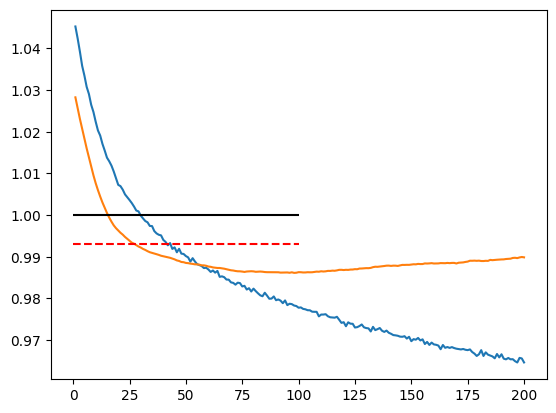

In [163]:
x = range(1, epochs+1)

plt.figure()

plt.plot(x, train_V, label='Train loss, V')
plt.plot(x, val_V, label='Val loss, V')
plt.hlines(1, color = 'black', linestyles='solid', xmin=0, xmax=100)
plt.hlines(baseline_V, color = 'red', linestyles='--', xmin=0, xmax=100, label='Baseline to beat')
plt.xlim([0, epochs])
plt.legend()

plt.figure()
plt.plot(x, train_surpise, label='Train loss, surprise')
plt.plot(x, val_surpise, label='Val loss, surprise')
plt.hlines(1, color = 'black', linestyles='solid', xmin=0, xmax=100)
plt.hlines(baseline_surprise, color = 'red', linestyles='--', xmin=0, xmax=100, label='Baseline to beat')
plt.xlim([0, epochs])
plt.legend()

#### **Multi-task CNN implementation**

In [124]:
class RunSequenceDataset(Dataset):
    """
    One item = one run.

    Returns:
        x       : [n_trials, n_rois]
        y       : [n_trials, 2]   (multitask targets: surprise, V)
        length  : int
    """

    def __init__(self, records):
        self.records = records

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        X, y_joint, y_surprise, y_V, roi_names, y_names = load_saved_run(
            rec['npz_path'])

        X = X.astype(np.float32)
        y = y_joint.astype(np.float32)

        return {
            'x': torch.from_numpy(X),   # [T, R]
            'y': torch.from_numpy(y),   # [T, 2]
            'length': X.shape[0],
        }

class MultiTask1DCNN(nn.Module):
    """
    Shared temporal CNN with one head per task.

    Input:
        x: [B, T, R]

    Output:
        out: {
            'surprise': [B, T],
            'V': [B, T]
        }
    """

    def __init__(self, n_rois, hidden_channels=32, kernel_size=3, dropout=.1):
        super().__init__()

        if kernel_size % 2 == 0:
            raise ValueError("kernel_size should be odd.")

        self.n_rois = n_rois
        padding = kernel_size // 2

        self.conv1 = nn.Conv1d(
            in_channels=n_rois,
            out_channels=hidden_channels,
            kernel_size=kernel_size,
            padding=padding
        )
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        self.head_surprise = nn.Conv1d(hidden_channels, 1, kernel_size=1)
        self.head_V = nn.Conv1d(hidden_channels, 1, kernel_size=1)

    def forward(self, x):
        # x: [B, T, R]
        if x.ndim != 3:
            raise ValueError(f"Expected [B, T, R], got {x.shape}")
        if x.shape[-1] != self.n_rois:
            raise ValueError(f"Expected {self.n_rois} ROIs, got {x.shape[-1]}")

        x = x.transpose(1, 2).contiguous()   # [B, R, T]

        h = self.conv1(x)
        h = self.relu(h)

        y_surprise = self.head_surprise(h).squeeze(1)   # [B, T]
        y_V = self.head_V(h).squeeze(1)                 # [B, T]

        return {
            'surprise': y_surprise,
            'V': y_V
        }


# Training and validation/test epochs

def train_epoch(model, dataloader, optimizer, criterion, device, w_surprise=1.0, w_V=1.0):
    model.train()

    total_loss_sum = 0.0
    surprise_loss_sum = 0.0
    V_loss_sum = 0.0
    n_batches = 0

    for batch in dataloader:
        x = batch['x'].to(device)   # [B, T, R]
        y = batch['y'].to(device)   # [B, T, 2]

        optimizer.zero_grad()

        outputs = model(x)
        loss, loss_surprise, loss_V = multitask_loss_fn(
            outputs=outputs,
            y_true=y,
            criterion=criterion,
            w_surprise=w_surprise,
            w_V=w_V
        )

        loss.backward()
        optimizer.step()

        total_loss_sum += loss.item()
        surprise_loss_sum += loss_surprise.item()
        V_loss_sum += loss_V.item()
        n_batches += 1

    return {
        'loss': total_loss_sum / n_batches,
        'loss_surprise': surprise_loss_sum / n_batches,
        'loss_V': V_loss_sum / n_batches
    }


def val_epoch(model, dataloader, criterion, device, w_surprise=1.0, w_V=1.0):
    model.eval()

    total_loss_sum = 0.0
    surprise_loss_sum = 0.0
    V_loss_sum = 0.0
    n_batches = 0

    with torch.no_grad():
        for batch in dataloader:
            x = batch['x'].to(device)
            y = batch['y'].to(device)

            outputs = model(x)
            loss, loss_surprise, loss_V = multitask_loss_fn(
                outputs=outputs,
                y_true=y,
                criterion=criterion,
                w_surprise=w_surprise,
                w_V=w_V
            )

            total_loss_sum += loss.item()
            surprise_loss_sum += loss_surprise.item()
            V_loss_sum += loss_V.item()
            n_batches += 1

    return {
        'loss': total_loss_sum / n_batches,
        'loss_surprise': surprise_loss_sum / n_batches,
        'loss_V': V_loss_sum / n_batches
    }


def multitask_loss_fn(outputs, y_true, criterion, w_surprise=1.0, w_V=1.0):
    if y_true.ndim != 3 or y_true.shape[-1] != 2:
        raise ValueError(
            f"Expected y_true shape [B, T, 2], got {tuple(y_true.shape)}")

    y_surprise = y_true[:, :, 0]
    y_V = y_true[:, :, 1]

    loss_surprise = criterion(outputs['surprise'], y_surprise)
    loss_V = criterion(outputs['V'], y_V)

    weighted_sum = w_surprise * loss_surprise + w_V * loss_V
    weight_total = w_surprise + w_V
    mean_loss = weighted_sum / weight_total

    return mean_loss, loss_surprise, loss_V


def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=20,
    w_surprise=1.0,
    w_V=1.0
):
    history = {
        'train_loss': [],
        'train_loss_surprise': [],
        'train_loss_V': [],
        'val_loss': [],
        'val_loss_surprise': [],
        'val_loss_V': []
    }

    best_val_loss = float('inf')
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        train_metrics = train_epoch(
            model=model,
            dataloader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
            w_surprise=w_surprise,
            w_V=w_V
        )

        val_metrics = val_epoch(
            model=model,
            dataloader=val_loader,
            criterion=criterion,
            device=device,
            w_surprise=w_surprise,
            w_V=w_V
        )

        history['train_loss'].append(train_metrics['loss'])
        history['train_loss_surprise'].append(train_metrics['loss_surprise'])
        history['train_loss_V'].append(train_metrics['loss_V'])

        history['val_loss'].append(val_metrics['loss'])
        history['val_loss_surprise'].append(val_metrics['loss_surprise'])
        history['val_loss_V'].append(val_metrics['loss_V'])

        if val_metrics['loss'] < best_val_loss and epoch > 3:
            best_val_loss = val_metrics['loss']
            best_state = copy.deepcopy(model.state_dict())

        # wandb.log({
        #     'epoch': epoch + 1,
        #     'train_loss': train_metrics['loss'],
        #     'train_loss_surprise': train_metrics['loss_surprise'],
        #     'train_loss_V': train_metrics['loss_V'],
        #     'val_loss': val_metrics['loss'],
        #     'val_loss_surprise': val_metrics['loss_surprise'],
        #     'val_loss_V': val_metrics['loss_V'],
        # })

        print(
            f"Epoch {epoch + 1:02d}/{epochs:02d} | "
            f"train_total={train_metrics['loss']:.4f} | "
            f"train_surprise={train_metrics['loss_surprise']:.4f} | "
            f"train_V={train_metrics['loss_V']:.4f} | "
            f"val_total={val_metrics['loss']:.4f} | "
            f"val_surprise={val_metrics['loss_surprise']:.4f} | "
            f"val_V={val_metrics['loss_V']:.4f}"
        )

    model.load_state_dict(best_state)
    return history, best_val_loss


def run_sweep_train():
    with wandb.init():
        config = wandb.config

        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        # Datasets
        train_dataset = RunSequenceDataset(train)
        val_dataset = RunSequenceDataset(val)

        # DataLoaders: batch_size comes from sweep
        train_loader = DataLoader(
            train_dataset,
            batch_size=config.batch_size,
            shuffle=True,
            num_workers=0
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=config.batch_size,
            shuffle=False,
            num_workers=0
        )

        # Infer n_rois from one sample
        sample = train_dataset[0]
        n_rois = sample['x'].shape[-1]

        model = MultiTask1DCNN(
            n_rois=n_rois,
            hidden_channels=config.hidden_channels,
            kernel_size=config.kernel_size,
            dropout=config.dropout
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=config.lr)
        criterion = nn.MSELoss()

        history, best_val_loss = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
            epochs=100
        )

        # Explicit final log for sweep metric
        wandb.log({'best_val_loss': best_val_loss, 'val_loss': best_val_loss})


sweep_config = {
    'method': 'bayes',
    'metric': {
        'name': 'val_loss',
        'goal': 'minimize'
    },
    'parameters': {
        'dropout': {
            'values': [0.3, 0.4, 0.5]
        },
        'hidden_channels': {
            'values': [2, 4, 6, 8, 16]
        },
        'kernel_size': {
            'values': [3, 5, 7]
        },
        'batch_size': {
            'values': [1, 4, 8, 16]
        },
        'lr': {
            'values': [1e-3, 5e-3, 1e-2]
        }
    }
}

pprint.pprint(sweep_config)

# Commented out so that hyperparameter tuning doesn't begin
# sweep_id = wandb.sweep(sweep_config, project='multitask-1dcnn-runs')
# wandb.agent(sweep_id, function=run_sweep_train)

{'method': 'bayes',
 'metric': {'goal': 'minimize', 'name': 'val_loss'},
 'parameters': {'batch_size': {'values': [1, 4, 8, 16]},
                'dropout': {'values': [0.3, 0.4, 0.5]},
                'hidden_channels': {'values': [2, 4, 6, 8, 16]},
                'kernel_size': {'values': [3, 5, 7]},
                'lr': {'values': [0.001, 0.005, 0.01]}}}


In [133]:
# Datasets
train_dataset = RunSequenceDataset(train)
val_dataset = RunSequenceDataset(val)
test_dataset = RunSequenceDataset(test)

# DataLoaders: batch_size comes from sweep
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
)

sample_batch = next(iter(train_loader))
n_rois = sample_batch['x'].shape[-1]

model = MultiTask1DCNN(
    n_rois=n_rois,
    hidden_channels=3,
    kernel_size=3,
    dropout=.4
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

epochs = 200

history, best_val_loss = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=epochs
)

test_metrics = val_epoch(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    device=device,
    w_surprise=1.75,
    w_V=1.0
)

print(
    f"Test total={test_metrics['loss']:.4f} | "
    f"Test surprise={test_metrics['loss_surprise']:.4f} | "
    f"Test V={test_metrics['loss_V']:.4f}"
)

Epoch 01/200 | train_total=1.0575 | train_surprise=1.0697 | train_V=1.0453 | val_total=1.0564 | val_surprise=1.0846 | val_V=1.0283
Epoch 02/200 | train_total=1.0524 | train_surprise=1.0623 | train_V=1.0424 | val_total=1.0509 | val_surprise=1.0761 | val_V=1.0256
Epoch 03/200 | train_total=1.0473 | train_surprise=1.0554 | train_V=1.0392 | val_total=1.0457 | val_surprise=1.0683 | val_V=1.0231
Epoch 04/200 | train_total=1.0427 | train_surprise=1.0497 | train_V=1.0358 | val_total=1.0412 | val_surprise=1.0615 | val_V=1.0208
Epoch 05/200 | train_total=1.0393 | train_surprise=1.0451 | train_V=1.0335 | val_total=1.0370 | val_surprise=1.0557 | val_V=1.0184
Epoch 06/200 | train_total=1.0359 | train_surprise=1.0411 | train_V=1.0308 | val_total=1.0333 | val_surprise=1.0506 | val_V=1.0160
Epoch 07/200 | train_total=1.0336 | train_surprise=1.0381 | train_V=1.0291 | val_total=1.0301 | val_surprise=1.0464 | val_V=1.0138
Epoch 08/200 | train_total=1.0305 | train_surprise=1.0346 | train_V=1.0265 | val_to

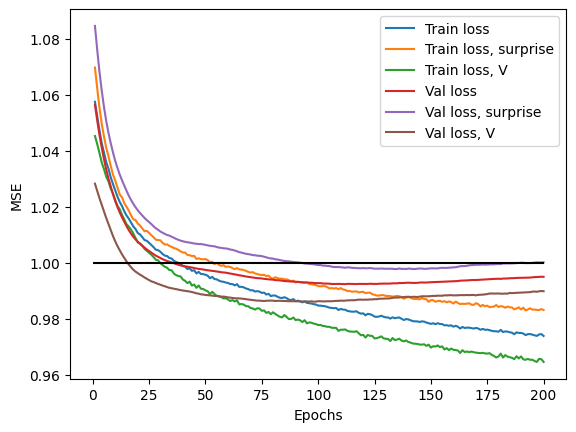

In [146]:
train_loss = np.array(history['train_loss'])
train_surpise = np.array(history['train_loss_surprise'])
train_V = np.array(history['train_loss_V'])

val_loss = np.array(history['val_loss'])
val_surpise = np.array(history['val_loss_surprise'])
val_V = np.array(history['val_loss_V'])

x = range(1, epochs+1)

plt.figure()
plt.plot(x, train_loss, label='Train loss')
plt.plot(x, train_surpise, label='Train loss, surprise')
plt.plot(x, train_V, label='Train loss, V')
plt.plot(x, val_loss, label='Val loss')
plt.plot(x, val_surpise, label='Val loss, surprise')
plt.plot(x, val_V, label='Val loss, V')
plt.hlines(1, color = 'black', linestyles='solid', xmin=0, xmax=200)
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()

## **Experimental Results**

Across all experiments, model performance was quite poor in absolute terms, but the results still form a coherent pattern. None of the tested methods achieved strong predictive accuracy, and most test metrics remained close to baseline, with mean squared errors generally near 1 and R^2 values near 0. Even so, the models did not behave randomly. Several runs showed consistent reductions in training and validation loss, and some methods produced small but repeatable improvements over simple baselines. Taken together, this suggests that the dataset contains decodable information about the target learning signals, but that the current feature representation does not expose that information in a form that is easy for standard machine learning models to exploit.

The ST linear models establish an important baseline for this interpretation. For V, Lasso performed slightly better than Ridge, getting a test MSE of 0.9955 and a small positive test R^2 of 0.0032, whereas Ridge reached a test MSE of 0.9971 with R^2=0.0016. These are weak results, but they are still informative: the fact that regularized linear models could do slightly better than a null predictor indicates that the ROI-level features retain at least a small amount of usable structure related to V. For surprise, however, both linear models failed to generalize well. Lasso produced a test MSE of 1.0035 and Ridge 1.0089, with both R^2 values falling below zero. This difference between V and surprise already hints that the two targets are not equally recoverable from the current encoding of BOLD activity.

The comparison between Lasso and Ridge is also revealing at the methodology level. Lasso consistently found lower validation error than Ridge, particularly for V, suggesting that sparse selection of informative ROIs may be more appropriate than distributing weight broadly across all features. In other words, the predictive signal may be weak and localized rather than globally distributed across the full ROI vector. This conclusion would support the claims made in [1] regarding the seperation and localization neural structures. That said, the gains were extremely small, which limits any strong conclusion. The more defensible interpretation is that the linear structure in the current features is minimal, and regularization mainly helps prevent overfitting rather than unlock predictive power.

The ST CNN results provide stronger evidence that the models are learning something real, even if the final test performances were poor. For V, the CNN improved from an initial validation loss above 1.10 down to roughly 0.987 at its best, and achieved a final test loss of 0.9812. This is meaningfully better than the zero baseline test loss of 0.9929. That margin is not large, but it is too systematic to dismiss as noise, especially given the long and downward trajectory during training. The model appears to extract a weak nonlinear signal from the event-level ROI features, implying that the relationship between BOLD activity and V is not purely linear. In practical terms, this makes the V CNN the strongest result of the two ST CNNs, even though it is still far from a strong decoder.

The ST CNN for surprise tells a different story. Its training loss decreased from about 1.06 to the high 0.97 range, showing that the model could fit patterns in the training data, but validation and test performance remained almost exactly at baseline. The final test loss was 1.0008, essentially indistinguishable from the zero baseline of 1.0000. This pattern strongly suggests that surprise is much harder than V to decode from the current representation. The issue does not appear to be that neural networks cannot learn at all; rather that the extracted event windows and averaged ROI activations do not preserve enough target-relevant information for surprise to generalize. Since surprise is theoretically a structure-learning signal tied to the unexpectedness of a presented multisensory combination, it may depend on finer temporal dynamics or context that is lost when BOLD data is reduced to averaged post-HRF ROI features.

The MT CNN results are especially important because they speak directly to the project’s central hypothesis. If V and surprise shared enough neural representation at the level captured by the features, then joint prediction should have improved performance through shared supervision. That did not happen. The multitask Elastic Net achieved a combined test MSE of 0.9971 with a very small positive R^2 of 0.0023, which is competitive with the weaker single-task linear models but not better than the best single-task results. The multitask CNN showed clearer learning during training, with validation total loss dropping from about 1.056 to about 0.993 at its best, but its final test results were still disappointing: total test loss was 1.0054, with surprise at 1.0119 and V at 0.9940. Notably, the MT CNN’s V result was worse than the single-task CNN’s 0.9812, and its surprise result was also worse than the already weak single-task surprise CNN. Joint learning therefore appears to have introduced interference rather than beneficial sharing. One other complicating factor was parameter weights hyperparameter of the MT CNN model. It's loss function is a weighted sum of the losses of the individual signals. When setting the two signals to have equal priority, the validation and test loss of V frequently beat out all other models; however in the cases it came at the cost of surprise losses higher than all other models.

This pattern aligns well with the theoretical framing of the problem. The motivating neuroscience suggests that V and surprise are connected within the broader multisensory learning system, but they arise from partially dissociable neurocomputational mechanisms rather than from a single unified neural unit. The experimental findings here are consistent with that view. V appears slightly more decodable than surprise, and forcing the model to learn both simultaneously does not help. In fact, the MT underperformance supports the idea that whatever overlap exists between the two signals is not strong enough, at least in the current ROI-averaged encoding, to support a beneficial shared representation. This does not disprove the existence of related neural mechanisms; instead, it suggests that the chosen feature space may blur together information that is functionally distinct at a finer spatial or temporal scale when neural activity is averaged over a window.

Overall, the results argue against the conclusion that machine learning was not applicable to the problem. The optimization traces show clear learning, especially for the V ST CNN and for the early stages of the MT CNN. Models repeatedly reduced validation loss, sometimes below baseline, which means they were detecting learnable patterns in the data. The more plausible interpretation is that the main bottleneck lies upstream, in how neural activity was encoded for prediction. Averaging activations over event windows after an HRF delay may have removed the temporal structure, context dependence, or region-specific variation needed to cleanly decode learning variables. Since linear models, sparse linear models, and nonlinear CNNs all struggled in similar ways, the evidence points less to a failure of machine learning methods in general and more to a limitation of the current BOLD feature representation. This makes sense at a hight level too when considering that I don't have a formal background in psycology, and that my idea of sensisble ROI encoding structure may not have been nuanced enough to extract meaningful information.

### **Permutation testing**

To further test the meaningfulness of my results, I also performed permutation tests, a type of statistical test in which an ML model’s performance on a dataset is compared against many recalculations of that performance with permuted labels. What this effectively does is create a null distribution of results. If the model trained on the real data does not perform much better on the non-shuffled test set than models trained on permuted, meaningless label assignments, and tested on the same test set then it suggests the original results were not statistically significant. The p-value of the test is the proportion of permutations that outperform the original model.

Permutation tests are especially useful in the current state of this experiment because the absolute performance metrics are weak and often very close to baseline. In that setting, standard evaluation scores alone do not clearly show whether a small improvement reflects genuine learning or just random variation in the data split. A permutation test addresses this directly by asking whether the observed performance is better than what would be expected if the relationship between BOLD features and learning targets were destroyed. This is particularly important here because the models do appear to learn some structure, but only weakly. The permutation framework therefore helps distinguish between poor but real signal decoding and results that are just lucky, making it a critical tool for interpreting the results of this project.


In [6]:
# Dataset extraction

X_train_list = []
y_V_train_list = []
y_surprise_train_list = []
X_val_list = []
y_V_val_list = []
y_surprise_val_list = []
X_test_list = []
y_V_test_list = []
y_surprise_test_list = []


for rec in train:
    X_run, _, y_surprise, y_V, roi_names, y_names = load_saved_run(
        rec['npz_path'])
    X_train_list.append(X_run)
    y_V_train_list.append(y_V.reshape(-1, 1))
    y_surprise_train_list.append(y_surprise.reshape(-1, 1))

X_train = np.vstack(X_train_list)
y_V_train = np.vstack(y_V_train_list).ravel()
y_surprise_train = np.vstack(y_surprise_train_list).ravel()

for rec in val:
    X_run, _, y_surprise, y_V, roi_names, y_names = load_saved_run(
        rec['npz_path'])
    X_val_list.append(X_run)
    y_V_val_list.append(y_V.reshape(-1, 1))
    y_surprise_val_list.append(y_surprise.reshape(-1, 1))

X_val = np.vstack(X_val_list)
y_V_val = np.vstack(y_V_val_list).ravel()
y_surprise_val = np.vstack(y_surprise_val_list).ravel()

for rec in test:
    X_run, _, y_surprise, y_V, roi_names, y_names = load_saved_run(
        rec['npz_path'])
    X_test_list.append(X_run)
    y_V_test_list.append(y_V.reshape(-1, 1))
    y_surprise_test_list.append(y_surprise.reshape(-1, 1))

X_test = np.vstack(X_test_list)
y_V_test = np.vstack(y_V_test_list).ravel()
y_surprise_test = np.vstack(y_surprise_test_list).ravel()

print(X_train.shape, y_V_train.shape, y_surprise_train.shape)


# Scale the data since normalization was previously performed at the run level for ROIs and subject level for labels

X_scaler = StandardScaler()
y_V_scaler = StandardScaler()
y_surprise_scaler = StandardScaler()

X_train = X_scaler.fit_transform(X_train)
X_val = X_scaler.transform(X_val)
X_test = X_scaler.transform(X_test)

y_V_train = y_V_scaler.fit_transform(y_V_train.reshape(-1, 1)).ravel()
y_V_val = y_V_scaler.transform(y_V_val.reshape(-1, 1)).ravel()
y_V_test = y_V_scaler.transform(y_V_test.reshape(-1, 1)).ravel()

y_surprise_train = y_surprise_scaler.fit_transform(
    y_surprise_train.reshape(-1, 1)
).ravel()
y_surprise_val = y_surprise_scaler.transform(
    y_surprise_val.reshape(-1, 1)
).ravel()
y_surprise_test = y_surprise_scaler.transform(
    y_surprise_test.reshape(-1, 1)
).ravel()

# Check that scaling worked
print("X_train_scaled mean (first 5 cols):", X_train.mean(axis=0)[:5])
print("X_train_scaled std  (first 5 cols):", X_train.std(axis=0)[:5])
print("y_V_train_scaled mean:", y_V_train.mean())
print("y_V_train_scaled std :", y_V_train.std())
print("y_surprise_train_scaled mean:", y_surprise_train.mean())
print("y_surprise_train_scaled std :", y_surprise_train.std())

(16560, 100) (16560,) (16560,)
X_train_scaled mean (first 5 cols): [ 2.2573774e-08 -1.1956922e-08  5.6170897e-08 -4.2900226e-08
 -1.4816217e-07]
X_train_scaled std  (first 5 cols): [0.9999989  1.         0.9999991  0.99999815 0.9999996 ]
y_V_train_scaled mean: 1.9234736e-08
y_V_train_scaled std : 1.0
y_surprise_train_scaled mean: -7.054656e-10
y_surprise_train_scaled std : 1.0


In [7]:
def permute_within_runs(records, rng, permute=True):
    """
    records: list of run records
    returns: X and y, with labels shuffled independently within each run
    """
    X_list = []
    y_V_list = []

    for rec in records:
        X_run, _, _, y_V, _, _ = load_saved_run(rec['npz_path'])
        X_list.append(X_run)

        y_run = y_V.reshape(-1, 1)
        if permute:
            y_run = rng.permutation(y_run)  # row-wise permutation
        y_V_list.append(y_run)

    X = np.vstack(X_list)
    y_V = np.vstack(y_V_list).ravel()
    return X, y_V


def permute_within_runs_multitask(records, rng, permute=True):
    """
    records: list of run records
    returns:
        X: shape (n_samples, n_features)
        y: shape (n_samples, 2) with columns [y_V, y_surprise]
    """
    X_list = []
    y_V_list = []
    y_surprise_list = []

    for rec in records:
        X_run, _, y_surprise, y_V, _, _ = load_saved_run(rec["npz_path"])
        X_list.append(X_run)

        y_V_run = y_V.reshape(-1, 1)
        y_surprise_run = y_surprise.reshape(-1, 1)   # fixed typo

        if permute:
            # shuffle each target independently within each run
            y_V_run = rng.permutation(y_V_run)
            y_surprise_run = rng.permutation(y_surprise_run)

        y_V_list.append(y_V_run)
        y_surprise_list.append(y_surprise_run)

    X = np.vstack(X_list)
    y_V = np.vstack(y_V_list)
    y_surprise = np.vstack(y_surprise_list)

    y = np.hstack([y_V, y_surprise])   # shape (n_samples, 2)
    return X, y


def fit_lasso_with_val_tuning(
    X_train, y_train,
    X_val, y_val,
    alpha_grid
):
    best_alpha = None
    best_val_mse = float("inf")

    for alpha in alpha_grid:
        model = sk.linear_model.Lasso(
            alpha=alpha,
            max_iter=1000000,
            random_state=SEED
        )
        model.fit(X_train, y_train)

        val_pred = model.predict(X_val)
        val_mse = mean_squared_error(y_val, val_pred)

        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_alpha = alpha

    return best_alpha, best_val_mse


def retrain_and_test_lasso(
    X_train, y_train,
    X_test, y_test,
    best_alpha
):
    model = sk.linear_model.Lasso(
        alpha=best_alpha,
        max_iter=1000000,
        random_state=SEED
    )
    model.fit(X_train, y_train)

    test_pred = model.predict(X_test)
    test_mse = mean_squared_error(y_test, test_pred)

    return model, test_mse


def run_pipeline_lasso(train, val, test, alpha_grid, rng, permute=True):
    X_train, y_V_train = permute_within_runs(train, rng, permute)
    X_val, y_V_val = permute_within_runs(val, rng, permute)
    X_test, y_V_test = permute_within_runs(test, rng, permute)

    # Scale using training statistics only
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train = x_scaler.fit_transform(X_train)
    X_val = x_scaler.transform(X_val)
    X_test = x_scaler.transform(X_test)

    y_V_train = y_scaler.fit_transform(y_V_train.reshape(-1, 1)).ravel()
    y_V_val = y_scaler.transform(y_V_val.reshape(-1, 1)).ravel()
    y_V_test = y_scaler.transform(y_V_test.reshape(-1, 1)).ravel()

    best_alpha, best_val_mse = fit_lasso_with_val_tuning(
        X_train, y_V_train, X_val, y_V_val, alpha_grid
    )

    final_model, test_mse = retrain_and_test_lasso(
        X_train, y_V_train, X_test, y_V_test, best_alpha
    )

    return final_model, best_alpha, best_val_mse, test_mse


def run_permutation_test_lasso(
    train, val, test,
    alpha_grid=np.logspace(-4, 1, 30),
    n_permutations=1000,
    seed=SEED,
):
    print('Testing LASSO')

    rng = np.random.default_rng(seed)

    # Baseline model
    baseline_model, baseline_alpha, baseline_val_mse, baseline_mse = run_pipeline_lasso(
        train, val, test, alpha_grid, rng, permute=False
    )

    # Null distribution
    permuted_mses = []

    for i in range(n_permutations):

        if i % 100 == 0:
            print('Processing permutation ', i)

        _, _, _, perm_mse = run_pipeline_lasso(
            train, val, test, alpha_grid, rng, permute=True
        )
        permuted_mses.append(perm_mse)

    permuted_mses = np.array(permuted_mses)

    # p-value
    p_value = (1 + np.sum(permuted_mses <= baseline_mse)) / \
        (n_permutations + 1)

    return {
        'baseline_mse': baseline_mse,
        'baseline_val_mse': baseline_val_mse,
        'baseline_alpha': baseline_alpha,
        'permuted_mses': permuted_mses,
        'p_value': p_value,
        'baseline_model': baseline_model,
    }


def fit_ridge_with_val_tuning(
    X_train, y_train,
    X_val, y_val,
    alpha_grid
):
    best_alpha = None
    best_val_mse = float("inf")

    for alpha in alpha_grid:
        model = sk.linear_model.Ridge(
            alpha=alpha,
            max_iter=1000000,
            random_state=SEED
        )
        model.fit(X_train, y_train)

        val_pred = model.predict(X_val)
        val_mse = mean_squared_error(y_val, val_pred)

        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_alpha = alpha

    return best_alpha, best_val_mse


def retrain_and_test_ridge(
    X_train, y_train,
    X_test, y_test,
    best_alpha
):
    model = sk.linear_model.Ridge(
        alpha=best_alpha,
        max_iter=1000000,
        random_state=SEED
    )
    model.fit(X_train, y_train)

    test_pred = model.predict(X_test)
    test_mse = mean_squared_error(y_test, test_pred)

    return model, test_mse


fit_ridge_with_val_tuning


def run_pipeline_ridge(train, val, test, alpha_grid, rng, permute=True):
    X_train, y_V_train = permute_within_runs(train, rng, permute)
    X_val, y_V_val = permute_within_runs(val, rng, permute)
    X_test, y_V_test = permute_within_runs(test, rng, permute)

    # Scale using training statistics only
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train = x_scaler.fit_transform(X_train)
    X_val = x_scaler.transform(X_val)
    X_test = x_scaler.transform(X_test)

    y_V_train = y_scaler.fit_transform(y_V_train.reshape(-1, 1)).ravel()
    y_V_val = y_scaler.transform(y_V_val.reshape(-1, 1)).ravel()
    y_V_test = y_scaler.transform(y_V_test.reshape(-1, 1)).ravel()

    best_alpha, best_val_mse = fit_ridge_with_val_tuning(
        X_train, y_V_train, X_val, y_V_val, alpha_grid
    )

    final_model, test_mse = retrain_and_test_ridge(
        X_train, y_V_train, X_test, y_V_test, best_alpha
    )

    return final_model, best_alpha, best_val_mse, test_mse


def run_permutation_test_ridge(
    train, val, test,
    alpha_grid=np.logspace(-4, 1, 30),
    n_permutations=1000,
    seed=SEED,
):
    print('Testing Ridge')

    rng = np.random.default_rng(seed)

    # Baseline model
    baseline_model, baseline_alpha, baseline_val_mse, baseline_mse = run_pipeline_ridge(
        train, val, test, alpha_grid, rng, permute=False
    )

    # Null distribution
    permuted_mses = []

    for i in range(n_permutations):

        if i % 100 == 0:
            print('Processing permutation ', i)

        _, _, _, perm_mse = run_pipeline_ridge(
            train, val, test, alpha_grid, rng, permute=True
        )
        permuted_mses.append(perm_mse)

    permuted_mses = np.array(permuted_mses)

    # p-value
    p_value = (1 + np.sum(permuted_mses <= baseline_mse)) / \
        (n_permutations + 1)

    return {
        'baseline_mse': baseline_mse,
        'baseline_val_mse': baseline_val_mse,
        'baseline_alpha': baseline_alpha,
        'permuted_mses': permuted_mses,
        'p_value': p_value,
        'baseline_model': baseline_model,
    }


def fit_multitask_elasticnet_with_val_tuning(
    X_train, y_train,
    X_val, y_val,
    pairs
):
    best_alpha = None
    best_l1_ratio = None
    best_val_mse = float("inf")

    for alpha, l1_ratio in pairs:
        model = sk.linear_model.MultiTaskElasticNet(
            alpha=alpha,
            l1_ratio=l1_ratio,
            max_iter=1000000,
            random_state=SEED
        )
        model.fit(X_train, y_train)

        val_pred = model.predict(X_val)
        val_mse = mean_squared_error(y_val, val_pred)

        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_alpha = alpha
            best_l1_ratio = l1_ratio

    return best_alpha, best_l1_ratio, best_val_mse


def retrain_and_test_multitask_elasticnet(
    X_train, y_train,
    X_test, y_test,
    best_alpha,
    best_l1_ratio
):
    model = sk.linear_model.MultiTaskElasticNet(
        alpha=best_alpha,
        l1_ratio=best_l1_ratio,
        max_iter=1000000,
        random_state=SEED
    )
    model.fit(X_train, y_train)

    test_pred = model.predict(X_test)
    test_mse = mean_squared_error(y_test, test_pred)

    return model, test_mse


def run_pipeline_multitask_elasticnet(
    train, val, test,
    pairs,
    rng,
    permute=True
):
    X_train, y_train = permute_within_runs_multitask(train, rng, permute)
    X_val, y_val = permute_within_runs_multitask(val, rng, permute)
    X_test, y_test = permute_within_runs_multitask(test, rng, permute)

    # Scale using training statistics only
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train = x_scaler.fit_transform(X_train)
    X_val = x_scaler.transform(X_val)
    X_test = x_scaler.transform(X_test)

    y_train = y_scaler.fit_transform(y_train)
    y_val = y_scaler.transform(y_val)
    y_test = y_scaler.transform(y_test)

    best_alpha, best_l1_ratio, best_val_mse = fit_multitask_elasticnet_with_val_tuning(
        X_train, y_train, X_val, y_val, pairs
    )

    final_model, test_mse = retrain_and_test_multitask_elasticnet(
        X_train, y_train, X_test, y_test, best_alpha, best_l1_ratio
    )

    return final_model, best_alpha, best_l1_ratio, best_val_mse, test_mse


def run_permutation_test_multitask_elasticnet(
    train, val, test,
    pairs=None,
    n_permutations=1000,
    seed=SEED,
):
    print("Testing MultiTaskElasticNet")

    if pairs is None:
        alphas = np.linspace(0.001, 10, 10)
        l1s = np.linspace(0.001, 1, 10)
        alpha_grid, l1_grid = np.meshgrid(alphas, l1s)
        pairs = np.column_stack([alpha_grid.ravel(), l1_grid.ravel()])

    rng = np.random.default_rng(seed)

    # Baseline model
    (
        baseline_model,
        baseline_alpha,
        baseline_l1_ratio,
        baseline_val_mse,
        baseline_mse,
    ) = run_pipeline_multitask_elasticnet(
        train, val, test,
        pairs, rng,
        permute=False
    )

    # Null distribution
    permuted_mses = []

    for i in range(n_permutations):
        if i % 100 == 0:
            print("Processing permutation", i)

        _, _, _, _, perm_mse = run_pipeline_multitask_elasticnet(
            train, val, test,
            pairs, rng,
            permute=True
        )
        permuted_mses.append(perm_mse)

    permuted_mses = np.array(permuted_mses)

    p_value = (1 + np.sum(permuted_mses <= baseline_mse)) / \
        (n_permutations + 1)

    return {
        "baseline_mse": baseline_mse,
        "baseline_val_mse": baseline_val_mse,
        "baseline_alpha": baseline_alpha,
        "baseline_l1_ratio": baseline_l1_ratio,
        "permuted_mses": permuted_mses,
        "p_value": p_value,
        "baseline_model": baseline_model,
        "pairs": pairs,
    }


# Perform test

if not os.path.exists('/content/project_repo/stats_tests/perm-tests-results-lasso.npz'):
    permutation_test_results_lasso = run_permutation_test_lasso(
        train, val, test)
    np.savez(
        '/content/project_repo/stats_tests/perm-tests-results-lasso.npz',
        permutation_test_results_lasso
    )
else:
    loaded = np.load(
        '/content/project_repo/stats_tests/perm-tests-results-lasso.npz', allow_pickle=True)
    permutation_test_results_lasso = loaded['arr_0'].item()

if not os.path.exists('/content/project_repo/stats_tests/perm-tests-results-ridge.npz'):
    permutation_test_results_ridge = run_permutation_test_ridge(
        train, val, test)
    np.savez(
        '/content/project_repo/stats_tests/perm-tests-results-ridge.npz',
        permutation_test_results_ridge
    )
else:
    loaded = np.load(
        '/content/project_repo/stats_tests/perm-tests-results-ridge.npz', allow_pickle=True)
    permutation_test_results_ridge = loaded['arr_0'].item()

if not os.path.exists("/content/project_repo/stats_tests/perm-tests-results-multitask-elasticnet.npz"):
    permutation_test_results_multitask = run_permutation_test_multitask_elasticnet(
        train, val, test
    )
    np.savez(
        "/content/project_repo/stats_tests/perm-tests-results-multitask-elasticnet.npz",
        permutation_test_results_multitask
    )
else:
    loaded = np.load(
        "/content/project_repo/stats_tests/perm-tests-results-multitask-elasticnet.npz",
        allow_pickle=True
    )
    permutation_test_results_multitask = loaded["arr_0"].item()

In [8]:
# Get parameters for plots

lasso = permutation_test_results_lasso['permuted_mses']
ridge = permutation_test_results_ridge['permuted_mses']

lasso_baseline = permutation_test_results_lasso['baseline_mse']
ridge_baseline = permutation_test_results_ridge['baseline_mse']

lasso_q10 = np.quantile(lasso, 0.10)
lasso_q05 = np.quantile(lasso, 0.05)
lasso_q01 = np.quantile(lasso, 0.01)

ridge_q10 = np.quantile(ridge, 0.10)
ridge_q05 = np.quantile(ridge, 0.05)
ridge_q01 = np.quantile(ridge, 0.01)

print('LASSO min: ', np.min(permutation_test_results_lasso['permuted_mses']),
      '\nLASSO max: ', np.max(permutation_test_results_lasso['permuted_mses']),
      '\nRidge min: ', np.min(permutation_test_results_ridge['permuted_mses']),
      '\nRidge max: ', np.max(permutation_test_results_ridge['permuted_mses']))

xmin = min(lasso.min(), ridge.min()) - .001
xmax = max(lasso.max(), ridge.max()) + .001

elasticnet = permutation_test_results_multitask['permuted_mses']
elasticnet_baseline = permutation_test_results_multitask['baseline_mse']

elasticnet_q10 = np.quantile(elasticnet, 0.10)
elasticnet_q05 = np.quantile(elasticnet, 0.05)
elasticnet_q01 = np.quantile(elasticnet, 0.01)

print(
    'ElasticNet min: ', np.min(
        permutation_test_results_multitask['permuted_mses']),
    '\nElasticNet max: ', np.max(
        permutation_test_results_multitask['permuted_mses'])
)

xmin_enet = elasticnet.min() - .001
xmax_enet = elasticnet.max() + .001

LASSO min:  0.9963685274124146 
LASSO max:  1.0095807313919067 
Ridge min:  0.9951438903808594 
Ridge max:  1.0199029445648193
ElasticNet min:  0.997829794883728 
ElasticNet max:  1.0047122240066528


[]

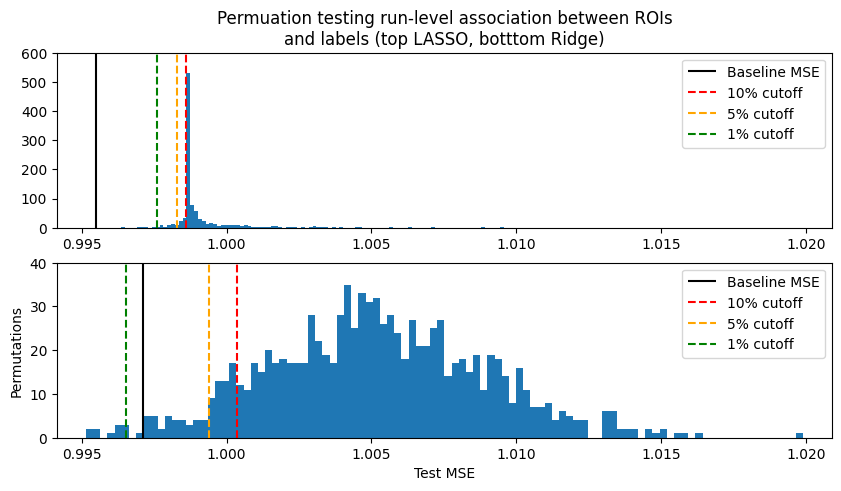

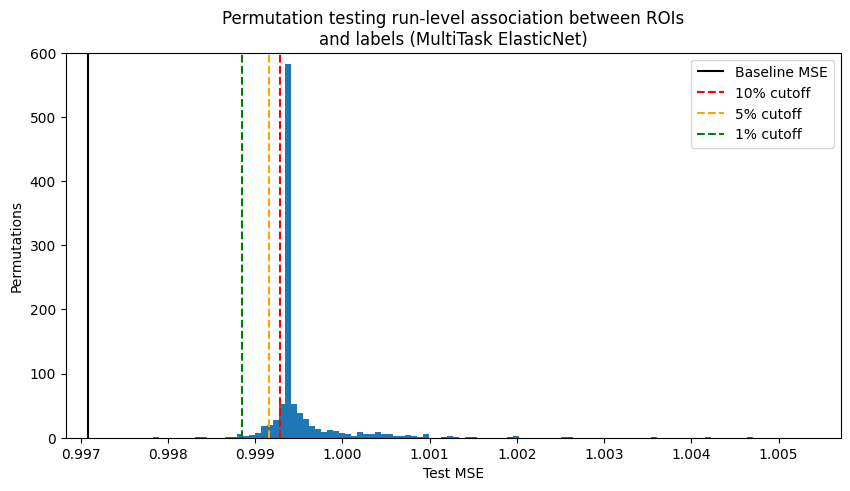

In [9]:
# Histograms

# Single-task models

plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.hist(lasso, bins=100)
plt.vlines(lasso_baseline, ymin=0,
           ymax=600, colors='black', label='Baseline MSE')
plt.vlines(lasso_q10, ymin=0,
           ymax=600, colors='red', label='10% cutoff', linestyles='--')
plt.vlines(lasso_q05, ymin=0,
           ymax=600, colors='orange', label='5% cutoff', linestyles='--')
plt.vlines(lasso_q01, ymin=0,
           ymax=600, colors='green', label='1% cutoff', linestyles='--')
plt.xlim((xmin, xmax))
plt.ylim([0, 600])
plt.title(
    'Permuation testing run-level association between ROIs\nand labels (top LASSO, botttom Ridge)')
plt.legend()
plt.plot()

plt.subplot(2, 1, 2)
plt.hist(ridge, 100)
plt.vlines(ridge_baseline, ymin=0,
           ymax=40, colors='black', label='Baseline MSE')
plt.vlines(ridge_q10, ymin=0,
           ymax=40, colors='red', label='10% cutoff', linestyles='--')
plt.vlines(ridge_q05, ymin=0,
           ymax=40, colors='orange', label='5% cutoff', linestyles='--')
plt.vlines(ridge_q01, ymin=0,
           ymax=40, colors='green', label='1% cutoff', linestyles='--')
plt.xlim([xmin, xmax])
plt.ylim([0, 40])
plt.ylabel('Permutations')
plt.xlabel('Test MSE')
plt.legend()
plt.plot()

# Multi-task model

plt.figure(figsize=(10, 5))
plt.hist(elasticnet, bins=100)
plt.vlines(elasticnet_baseline, ymin=0,
           ymax=600, colors='black', label='Baseline MSE')
plt.vlines(elasticnet_q10, ymin=0,
           ymax=600, colors='red', label='10% cutoff', linestyles='--')
plt.vlines(elasticnet_q05, ymin=0,
           ymax=600, colors='orange', label='5% cutoff', linestyles='--')
plt.vlines(elasticnet_q01, ymin=0,
           ymax=600, colors='green', label='1% cutoff', linestyles='--')
plt.xlim([xmin_enet, xmax_enet])
plt.ylim([0, 600])
plt.title('Permutation testing run-level association between ROIs\nand labels (MultiTask ElasticNet)')
plt.ylabel('Permutations')
plt.xlabel('Test MSE')
plt.legend()
plt.plot()

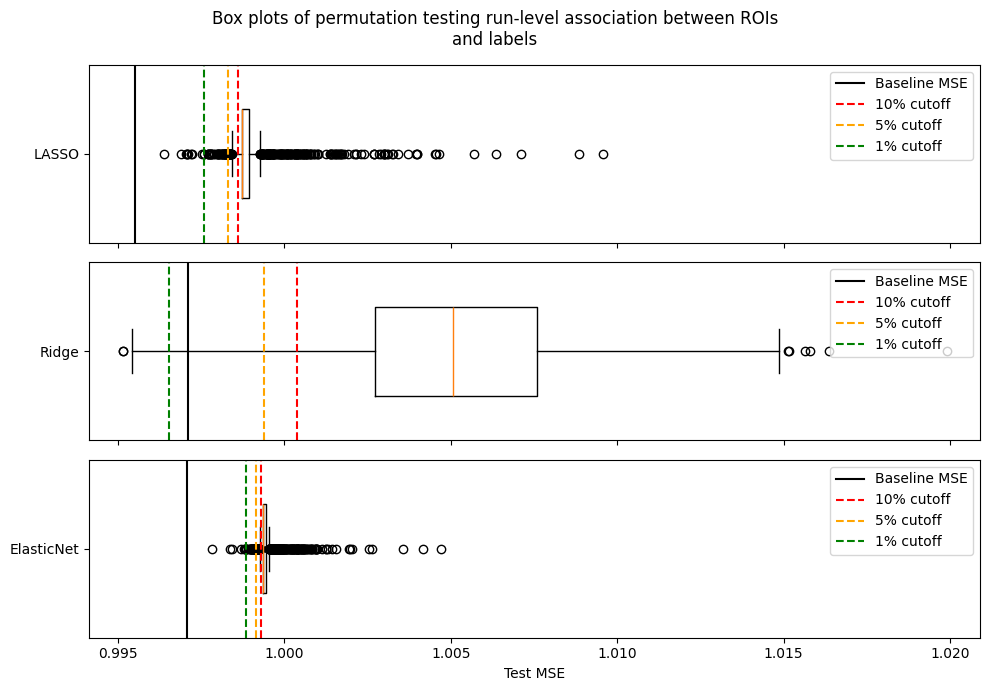

In [10]:
# Get parameters for plots

# Boxplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(10, 7))
fig.suptitle(
    'Box plots of permutation testing run-level association between ROIs\nand labels'
)

# LASSO
ax1.boxplot(lasso, vert=False, widths=0.5)
ax1.axvline(lasso_baseline, color='black', label='Baseline MSE')
ax1.axvline(lasso_q10, color='red', linestyle='--', label='10% cutoff')
ax1.axvline(lasso_q05, color='orange', linestyle='--', label='5% cutoff')
ax1.axvline(lasso_q01, color='green', linestyle='--', label='1% cutoff')
ax1.set_yticks([1])
ax1.set_yticklabels(['LASSO'])
ax1.legend(loc='upper right')

# Ridge
ax2.boxplot(ridge, vert=False, widths=0.5)
ax2.axvline(ridge_baseline, color='black', label='Baseline MSE')
ax2.axvline(ridge_q10, color='red', linestyle='--', label='10% cutoff')
ax2.axvline(ridge_q05, color='orange', linestyle='--', label='5% cutoff')
ax2.axvline(ridge_q01, color='green', linestyle='--', label='1% cutoff')
ax2.set_yticks([1])
ax2.set_yticklabels(['Ridge'])
ax2.legend(loc='upper right')

# Elastic Net
ax3.boxplot(elasticnet, vert=False, widths=0.5)
ax3.axvline(elasticnet_baseline, color='black', label='Baseline MSE')
ax3.axvline(elasticnet_q10, color='red', linestyle='--', label='10% cutoff')
ax3.axvline(elasticnet_q05, color='orange', linestyle='--', label='5% cutoff')
ax3.axvline(elasticnet_q01, color='green', linestyle='--', label='1% cutoff')
ax3.set_yticks([1])
ax3.set_yticklabels(['ElasticNet'])
ax3.set_xlabel('Test MSE')
ax3.legend(loc='upper right')

# Shared x-limits across all three
ax3.set_xlim(xmin, xmax)

plt.tight_layout()
plt.show()

The permutation tests add an important layer of interpretation to the raw performance metrics. Although the absolute test MSE values for the linear models were not especially strong, the null distributions show that the observed results were not equally likely under random label assignments. For both LASSO and MultiTask ElasticNet, the baseline MSE falls clearly to the left of the permutation distributions, meaning the real-label models performed better than almost all models trained on permuted labels. In the ElasticNet histogram this is especially visible: the baseline line sits well beyond the lower tail of the null distribution and even to the left of the 1% cutoff, which indicates that the observed result is unlikely to be explained by chance alone. The LASSO box plot tells a similar story, with the baseline also lying well to the left of the permutation mass and the main box of permuted results clustered closer to 1.0.

Ridge appears weaker and less decisive. Its baseline still lies in the favorable left tail of the null distribution, but not nearly as far from the permutation mass as LASSO or ElasticNet. That suggests Ridge may be capturing some real association, but less robustly and with greater sensitivity to noise. Taken together, these results support the broader interpretation of the project: the models are not performing well in an absolute sense, but they are detecting a real, non-random relationship between ROI-level BOLD features and the targets. This strengthens the argument that the main bottleneck is not the complete absence of learnable signal, but rather that the current neural encoding scheme preserves that signal only weakly.

## **Conclusions**

In conclusion, this project found that predicting learning-related signals from ROI-level fMRI data is possible in principle, but difficult in practice with the current feature encoding. Across all experiments, the best target-specific result was obtained for V under the ST CNN, which produced the strongest improvement over its baseline and the clearest evidence of learning during optimization. For surprise, none of the models achieved convincing predictive performance, even when training loss decreased. This asymmetry suggests that V is more recoverable than surprise from the current representation of event-aligned BOLD activity. More broadly, the results show that weak predictive signal exists in the data, but that it is not expressed in a way that standard linear or neural models can exploit efficiently.

The model comparison also gives a clear answer to the central question of whether shared modeling helped. In this project, MT learning did not outperform ST learning. Both the multitask ElasticNet and the multitask CNN were competitive in some settings, but neither surpassed the best ST result, and the MT CNN in particular underperformed the ST CNN on V. This matters because the original motivation for multitask learning was the idea that V and surprise might benefit from shared supervision if they were supported by overlapping neural representations. Instead, the results suggest that whatever relationship exists between the two signals is not strong or direct enough, at least in the current feature space, to improve joint prediction. In that sense, the project supports the interpretation that V and surprise are connected but still sufficiently distinct that forcing a shared predictive representation may introduce interference rather than help.

Some findings from the project are more robust than others. The most robust result is that models were not simply failing to optimize: several training curves showed smooth and sustained loss reduction, and permutation testing indicated that most of the observed performance was better than chance. This is especially important because the absolute metrics alone might suggest a complete absence of signal. Instead, the combination of optimization traces, baseline comparisons, and permutation results supports the claim that the dataset contains meaningful information about the targets. At the same time, important uncertainties remain. The absolute predictive quality is still low, surprise decoding remains weak, and the practical significance of the small gains over baseline is limited. It is therefore not yet possible to claim that the project has produced a strong decoding pipeline for latent learning signals from fMRI.

Overall, the project supports several conclusions, but it does not yet support others. It supports the claim that ROI-level BOLD features contain a weak but non-random relationship with V, and it supports the broader theoretical view that connected neurocomputational signals do not necessarily benefit from MT modeling when their underlying representations are only partially shared. However, the project does not yet support the stronger claim that ST methods are superior for this problem, nor does it support the claim that the current preprocessing and event encoding scheme is sufficient for reliable decoding of both targets. The weak results across many model classes suggest that the main bottleneck is not machine learning as a whole, but the representation of the neural data being given to the models.

The main limitations follow directly from that interpretation. The feature space was heavily compressed through ROI averaging and event-window aggregation, which likely removed temporal and spatial information that could be important for decoding. The sample size was also small relative to the complexity and noise of fMRI data, and the targets themselves are latent computational variables rather than directly observed behavioral labels. These constraints make overfitting, weak generalization, and unstable target recovery more likely. The next steps should therefore focus less on inventing increasingly complex models, and focus more on improving the neural encoding scheme. Promising directions include better event alignment, richer temporal representations, alternative ROI definitions, and sequence-based trial representations. If future work can preserve more of the relevant neural structure before modeling, then both ST and MT approaches can be reevaluated under conditions that better reflect the actual information present in the brain data.

## **References**

[1] S. Bedi, E. Casimiro, G. de Hollander, N. Raduner, F. Helmchen, S. Brem, A. Konovalov, and C. C. Ruff, “Separable neurocomputational mechanisms underlying multisensory learning,” bioRxiv, 2026, doi: 10.1101/2025.11.18.688925.

[2] S. Bedi, E. Casimiro, G. de Hollander, N. Raduner, F. Helmchen, S. Brem, A. Konovalov, and C. C. Ruff, “Multisensory learning dataset,” OpenNeuro, ver. 1.0.0, 2026, doi: 10.18112/openneuro.ds007436.v1.0.0.

[3] A. Schaefer, R. Kong, E. M. Gordon, T. O. Laumann, X.-N. Zuo, A. J. Holmes, S. B. Eickhoff, and B. T. T. Yeo, “Local-Global Parcellation of the Human Cerebral Cortex from Intrinsic Functional Connectivity MRI,” Cerebral Cortex, vol. 28, no. 9, pp. 3095–3114, 2018, doi: 10.1093/cercor/bhx179.

[4] O. Esteban et al., “fMRIPrep: a robust preprocessing pipeline for functional MRI,” Nature Methods, vol. 16, no. 1, pp. 111–116, 2019, doi: 10.1038/s41592-018-0235-4.

[5] Nilearn contributors, nilearn [Software]. Zenodo, doi: 10.5281/zenodo.8397156.


## **Acknowledgements**

I would like to thank my fried, Hiba Khalil, for their invaluable support and ecouragement in my pursuit of this project.